# Projet Analyse de Données — Jeu de données Steam
## 4MA – AD 2025-2026

---


## 1. Introduction et Problématique

La plateforme Steam regroupe plus de 120 000 jeux, des petits projets indépendants aux blockbusters mondiaux. Ce projet analyse les données de chaque titre (prix, genre, avis, temps de jeu, plateformes) en mobilisant les méthodes d'analyse factorielle, de clustering et, en complément, une modélisation linéaire.

**Problématique principale :** *Existe-t-il une structure latente du marché Steam permettant de regrouper les jeux en segments homogènes et interprétables à partir de leurs caractéristiques intrinsèques ?*

**Question complémentaire :** *Les composantes latentes identifiées par l'ACP permettent-elles de modéliser linéairement le succès d'un jeu ?*



---
## 2. Chargement et Premier Aperçu des Données


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

df_raw = pd.read_csv('games.csv')
print(f"Dimensions initiales : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
display(df_raw.head(3))


Dimensions initiales : 122,611 lignes × 39 colonnes


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN


---
## 3. Prétraitement et Qualité des Données

### 3.1 Analyse des Valeurs Manquantes


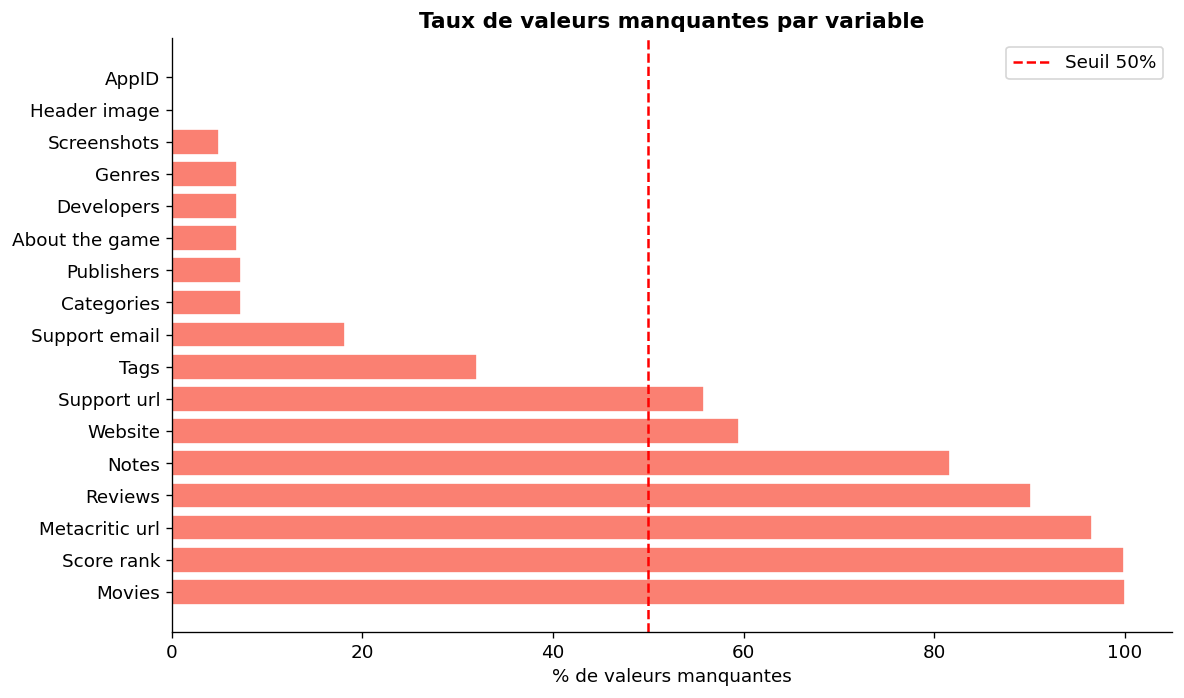

      Variable  % manquants
        Movies   100.000000
    Score rank    99.967376
Metacritic url    96.528860
       Reviews    90.155859
         Notes    81.683536
       Website    59.484875
   Support url    55.842461
          Tags    32.024044
 Support email    18.157425
    Categories     7.301955
    Publishers     7.266069
About the game     6.890899
    Developers     6.881112
        Genres     6.861538
   Screenshots     4.908206
  Header image     0.066063
         AppID     0.000816


In [2]:
# Taux de valeurs manquantes par variable
missing_pct = df_raw.isnull().mean().sort_values(ascending=False) * 100
missing_df = missing_pct[missing_pct > 0].reset_index()
missing_df.columns = ['Variable', '% manquants']

fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df)*0.35)))
bars = ax.barh(missing_df['Variable'], missing_df['% manquants'], color='salmon', edgecolor='white')
ax.axvline(50, color='red', linestyle='--', linewidth=1.5, label='Seuil 50%')
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Taux de valeurs manquantes par variable", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(missing_df.to_string(index=False))


**Lecture :** Les variables dépassant 50% de valeurs manquantes (comme `Score rank` ou `Metacritic url`) sont considérées non exploitables et seront supprimées. Les variables de type texte libre (descriptions, URLs) sont écartées car non utilisables pour l'analyse statistique.


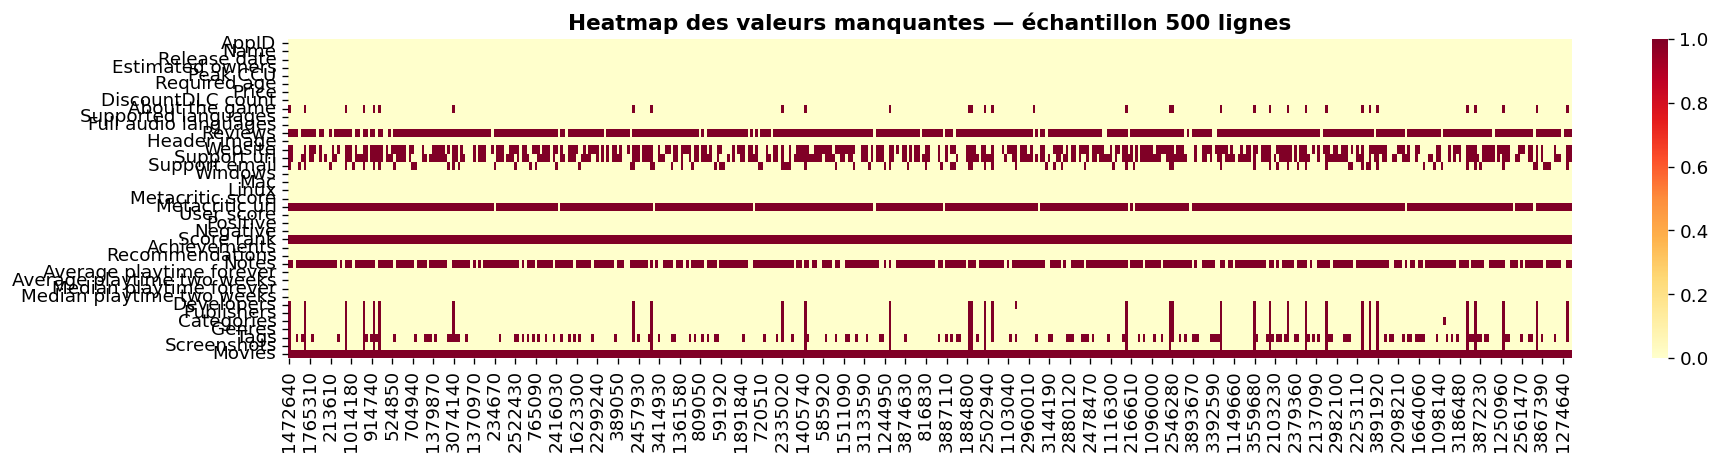

In [3]:
# Heatmap des valeurs manquantes sur un échantillon
plt.figure(figsize=(16, 4))
sns.heatmap(df_raw.isnull().sample(500, random_state=42).T,
            cbar=True, yticklabels=True, cmap='YlOrRd')
plt.title("Heatmap des valeurs manquantes — échantillon 500 lignes", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Lecture :** Chaque ligne représente une variable, chaque colonne un jeu. Les zones jaunes/rouges indiquent les données manquantes. On voit que les manquants ne sont pas aléatoires : certaines variables sont systématiquement absentes pour les petits jeux (pas de score Metacritic, pas d'âge requis).


### 3.2 Nettoyage et Encodage des Variables


In [4]:
df = df_raw.copy()

# Suppression des colonnes non pertinentes
cols_a_retirer = [
    'AppID', 'About the game', 'Notes', 'Reviews',
    'Header image', 'Website', 'Support url', 'Support email',
    'Metacritic url', 'Screenshots', 'Score rank', 'Movies', 'Tags'
]
df.drop(columns=cols_a_retirer, errors='ignore', inplace=True)

# Encodage des plateformes en binaire
for col in ['Windows', 'Mac', 'Linux']:
    if col in df.columns:
        df[col] = (df[col].astype(str).str.lower() == 'true').astype(int)

print(f"Dimensions après nettoyage : {df.shape[0]:,} × {df.shape[1]}")
print("\nVariables conservées :")
print(df.columns.tolist())


Dimensions après nettoyage : 122,611 × 26

Variables conservées :
['Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price', 'DiscountDLC count', 'Supported languages', 'Full audio languages', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'User score', 'Positive', 'Negative', 'Achievements', 'Recommendations', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks', 'Developers', 'Publishers', 'Categories', 'Genres']


*Les variables booléennes (Windows/Mac/Linux) sont converties en binaires 0/1 pour pouvoir être intégrées à l'analyse quantitative.*


### 3.3 Analyse Exploratoire Univariée et Transformations


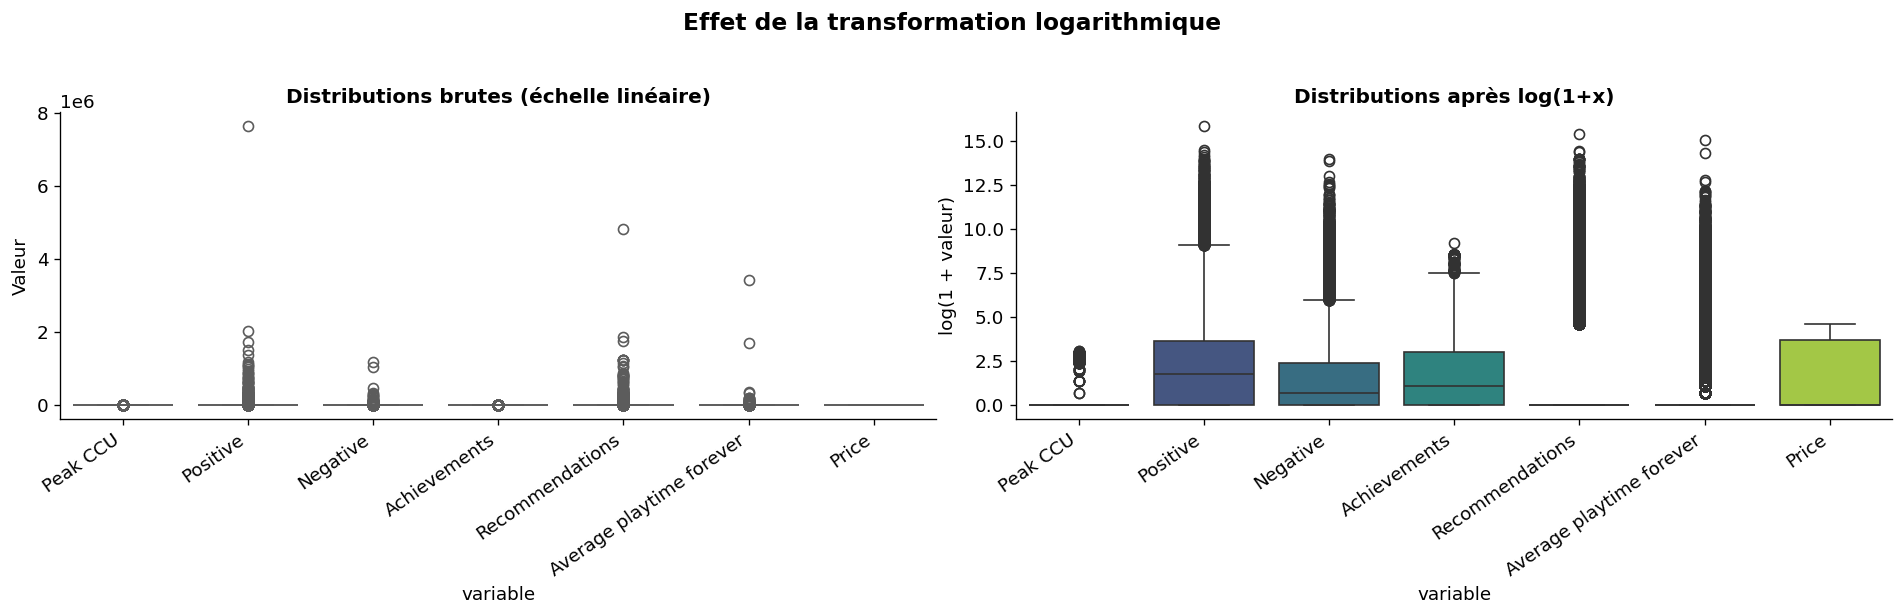

In [5]:
cols_num_viz = ['Peak CCU', 'Positive', 'Negative', 'Achievements',
                'Recommendations', 'Average playtime forever', 'Price']
cols_num_viz = [c for c in cols_num_viz if c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Avant transformation
df[cols_num_viz].melt().pipe(
    lambda d: sns.boxplot(data=d, x='variable', y='value',
                          palette='hls', ax=axes[0])
)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right')
axes[0].set_title("Distributions brutes (échelle linéaire)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Valeur")

# Après log(1+x)
df[cols_num_viz].apply(np.log1p).melt().pipe(
    lambda d: sns.boxplot(data=d, x='variable', y='value',
                          palette='viridis', ax=axes[1])
)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right')
axes[1].set_title("Distributions après log(1+x)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("log(1 + valeur)")

plt.suptitle("Effet de la transformation logarithmique", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Lecture :** À gauche, les distributions brutes sont illisibles à cause d'outliers extrêmes. À droite, la transformation log(1+x) stabilise la variance et rend les données comparables, ce qui est indispensable pour traiter la loi de puissance qui régit naturellement les métriques de popularité sur Steam.


---
## 4. Analyse Multidimensionnelle Préliminaire

### 4.1 Matrice de Corrélations


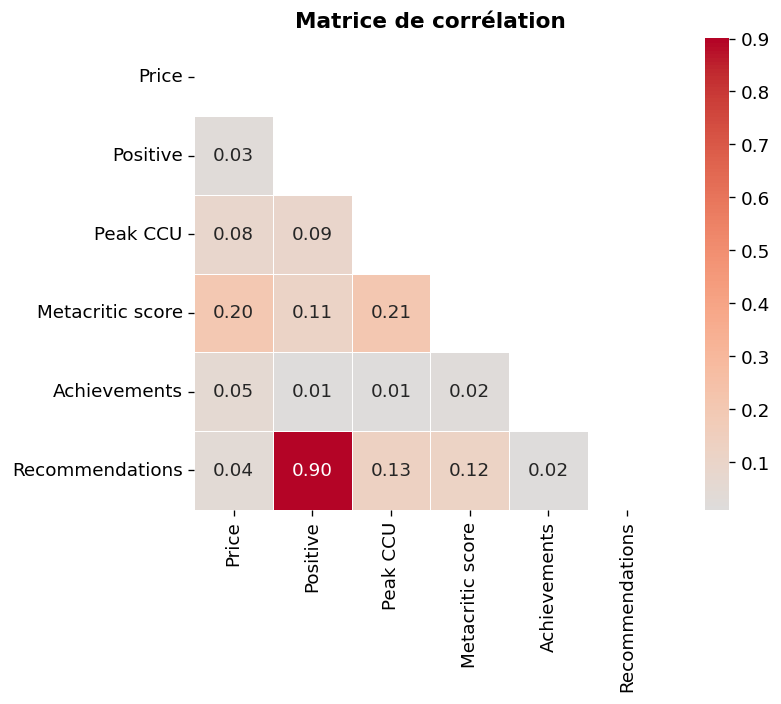

In [6]:
cols_quanti_corr = ['Price', 'Positive', 'DLC count', 'Peak CCU',
                   'Metacritic score', 'Achievements','Recommendations']
cols_quanti_corr = [c for c in cols_quanti_corr if c in df.columns]

data_corr = df[cols_quanti_corr].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(data_corr.corr(), dtype=bool))
sns.heatmap(data_corr.corr(), annot=True, fmt=".2f", cmap='coolwarm',
            center=0, linewidths=0.5, square=True, mask=mask)
plt.title("Matrice de corrélation", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Lecture :** Les variables de popularité et d'engagement (Positive, Peak CCU, Playtime) forment un bloc très corrélé, mesurant une seule et même dimension de succès. À l'inverse, le Price et le Metacritic score en sont fortement décorrélés. Il est essentiel de les conserver pour l'ACP : leur indépendance mathématique garantit qu'ils apporteront de l'information nouvelle (valeur et critique) pour construire des axes factoriels distincts de la simple popularité.


---
## 5. Analyse en Composantes Principales (ACP)


In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cols_quanti_pca = [
    'Peak CCU', 'Required age', 'Price', 'DLC count',
    'Metacritic score', 'User score', 'Positive', 'Negative',
    'Achievements', 'Recommendations',
    'Average playtime forever', 'Average playtime two weeks',
    'Median playtime forever', 'Median playtime two weeks'
]
cols_to_log = [
    'Peak CCU', 'Positive', 'Negative', 'Achievements', 'Recommendations',
    'Average playtime forever', 'Median playtime forever',
    'Average playtime two weeks', 'Median playtime two weeks'
]
cols_quanti_pca = [c for c in cols_quanti_pca if c in df.columns]
cols_to_log     = [c for c in cols_to_log if c in df.columns]

data_pca = df[cols_quanti_pca].apply(pd.to_numeric, errors='coerce').fillna(0)
for col in cols_to_log:
    data_pca[col] = np.log1p(data_pca[col])

scaler     = StandardScaler()
data_scaled = scaler.fit_transform(data_pca)

pca      = PCA()
pca_data = pca.fit_transform(data_scaled)

eigenvalues      = pca.explained_variance_
variance_ratio   = pca.explained_variance_ratio_ * 100
cum_variance     = np.cumsum(variance_ratio)

res_eig = pd.DataFrame({
    'Valeur propre'  : eigenvalues,
    '% variance'     : variance_ratio,
    '% cumulé'       : cum_variance
}, index=[f"Dim.{i+1}" for i in range(len(eigenvalues))])

n_axes = 3  # Choix basé sur le coude du scree plot (3 axes interprétables)
print(f"Variance expliquée cumulée ({n_axes} axes) : {cum_variance[n_axes-1]:.1f}%\n")
display(res_eig.round(3).head(10))


Variance expliquée cumulée (3 axes) : 59.4%



,Valeur propre,% variance,% cumulé
Dim.1,5.238,40.289,40.289
Dim.2,1.462,11.243,51.532
Dim.3,1.026,7.889,59.421
Dim.4,1.001,7.701,67.121
Dim.5,0.988,7.603,74.725
Dim.6,0.889,6.837,81.561
Dim.7,0.763,5.871,87.432
Dim.8,0.720,5.535,92.967
Dim.9,0.537,4.133,97.100
Dim.10,0.283,2.174,99.274


### 5.1 Scree Plot et Variance Cumulée


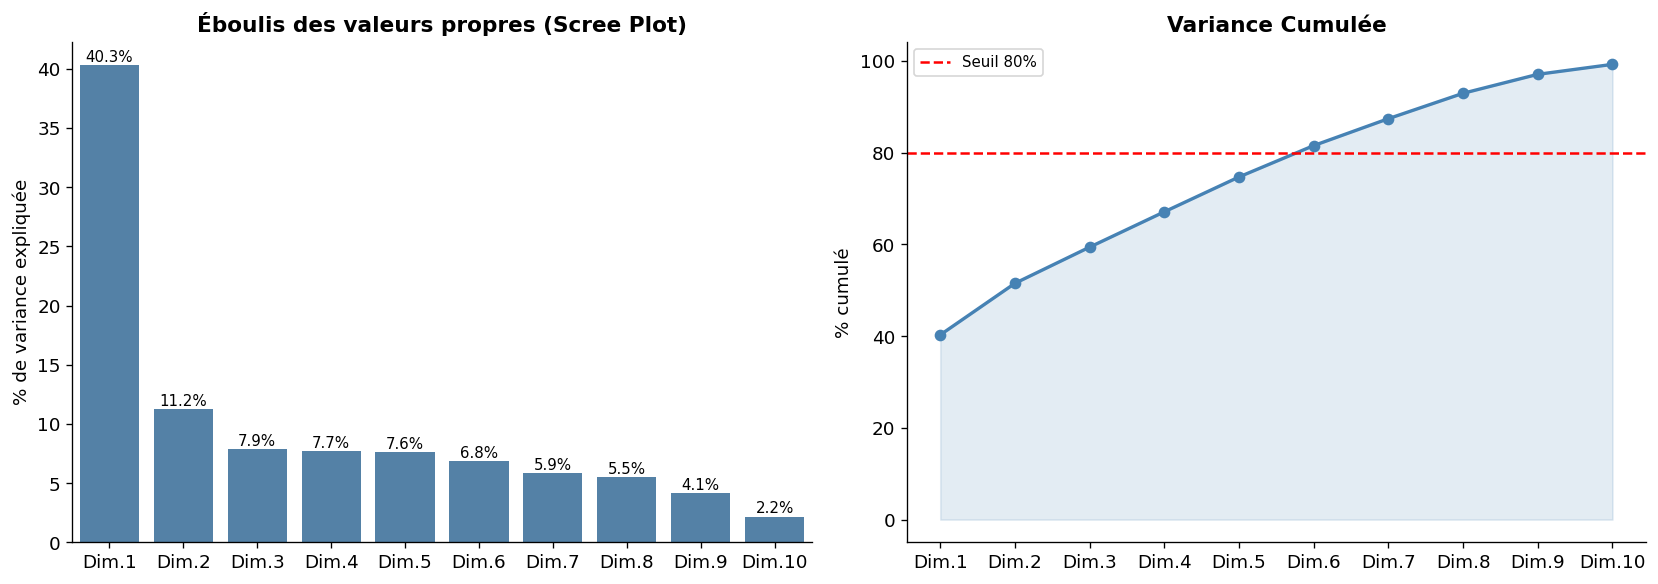

In [8]:
top_n = min(10, len(res_eig))
dims  = [f"Dim.{i+1}" for i in range(top_n)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
sns.barplot(x=dims, y=res_eig['% variance'][:top_n], color='steelblue', ax=ax1)
# seuil 1/p non utilisé
for i, v in enumerate(res_eig['% variance'][:top_n]):
    ax1.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontsize=9)
ax1.set_title("Éboulis des valeurs propres (Scree Plot)", fontsize=13, fontweight='bold')
ax1.set_ylabel("% de variance expliquée")

# Variance cumulée
ax2.plot(dims, cum_variance[:top_n], 'o-', color='steelblue', linewidth=2)
ax2.fill_between(range(top_n), cum_variance[:top_n], alpha=0.15, color='steelblue')
ax2.axhline(80, color='red', linestyle='--', label='Seuil 80%')
ax2.set_title("Variance Cumulée", fontsize=13, fontweight='bold')
ax2.set_ylabel("% cumulé")
ax2.set_xticks(range(top_n)); ax2.set_xticklabels(dims)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


**Lecture :** Le graphique de gauche montre une cassure nette après le 3ème axe : ajouter d'autres dimensions n'apporte presque plus d'information. La courbe de droite le confirme, puisque ces trois premiers axes suffisent à résumer l'essentiel des données (~60%). C'est pourquoi nous ne garderons que ces trois composantes pour la suite de l'analyse.


### 5.2 Cercles des Corrélations


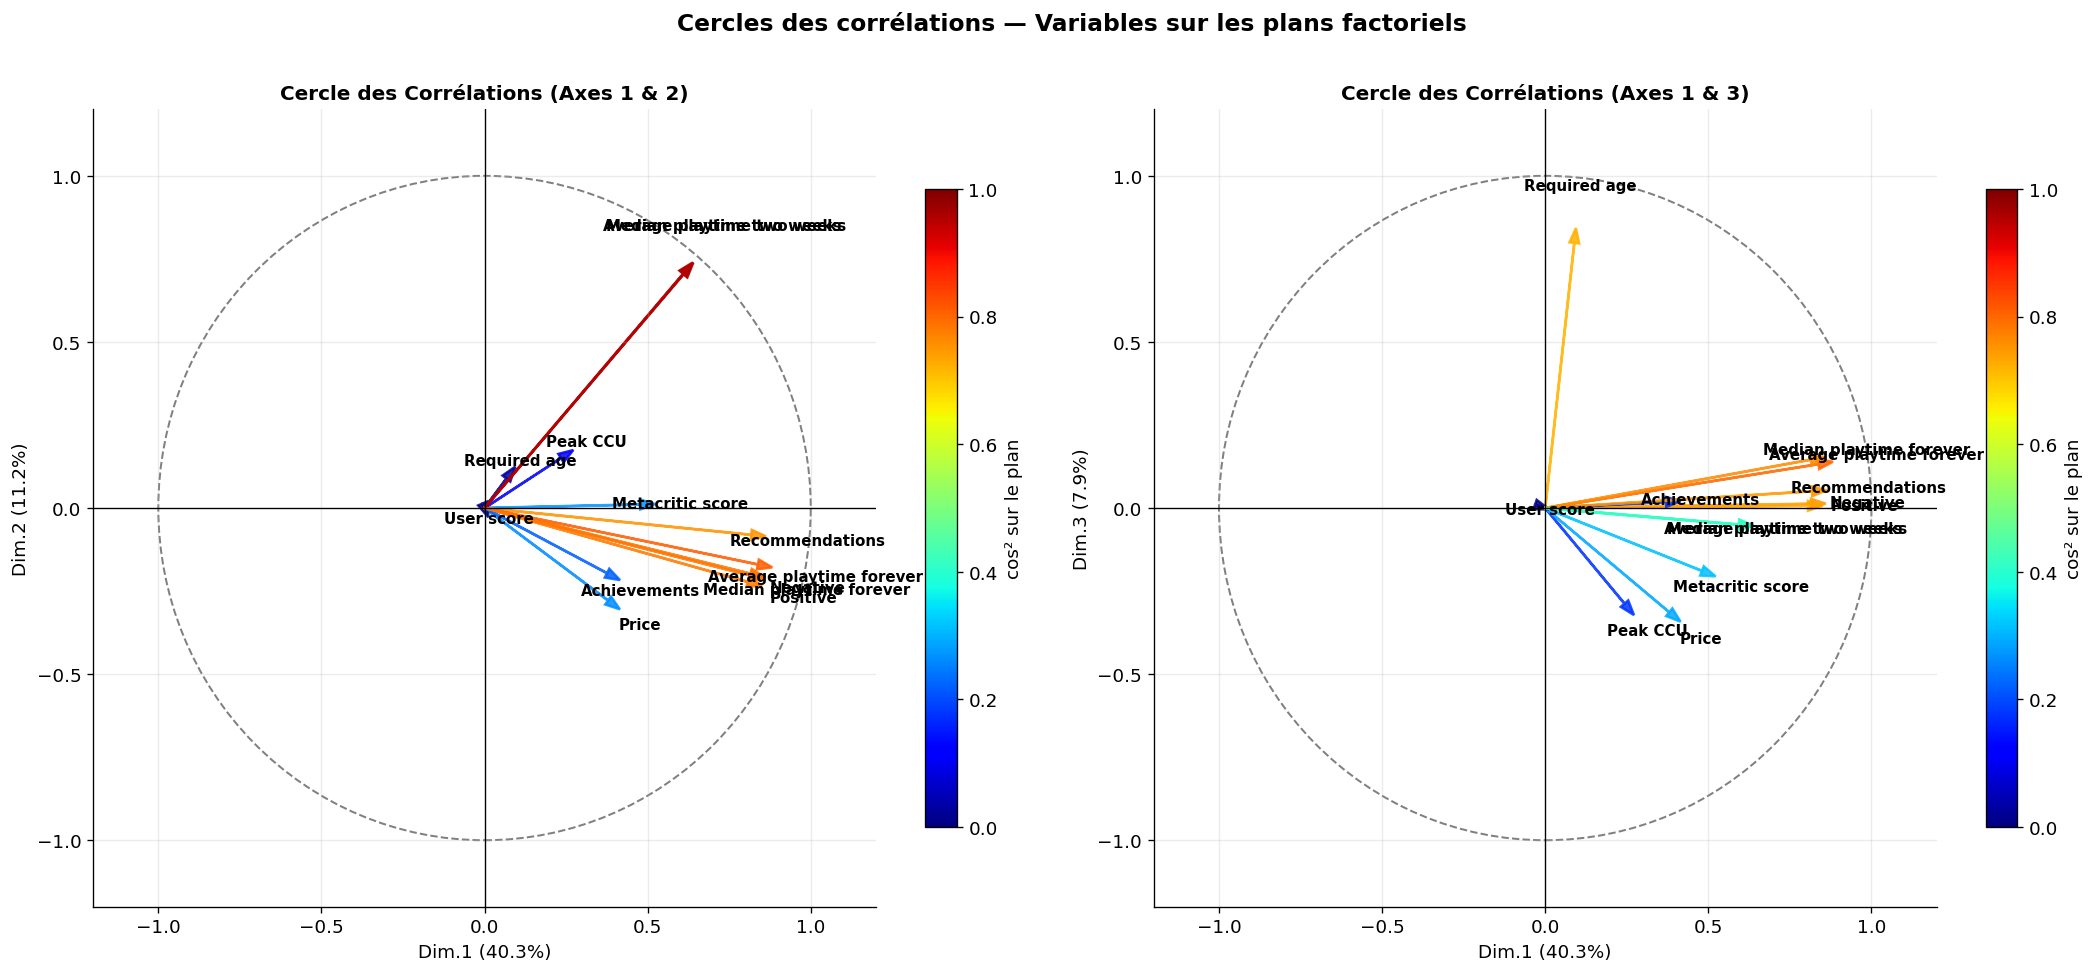

In [9]:
import matplotlib.cm as cm

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
cos2     = loadings**2

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axis_pairs = [(0, 1), (0, 2)]

for ax, (dx, dy) in zip(axes, axis_pairs):
    circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=1.2)
    ax.add_artist(circle)

    current_cos2 = cos2[:, dx] + cos2[:, dy]
    norm_  = plt.Normalize(0, 1)
    cmap_  = cm.get_cmap('jet')

    for j, feat in enumerate(cols_quanti_pca):
        xc, yc = loadings[j, dx], loadings[j, dy]
        color_ = cmap_(norm_(current_cos2[j]))
        ax.arrow(0, 0, xc, yc, color=color_, alpha=0.85,
                 head_width=0.03, length_includes_head=True, linewidth=1.5)
        ax.text(xc*1.15, yc*1.15, feat, ha='center', va='center',
                fontsize=9, fontweight='bold', color='black')

    ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
    ax.axhline(0, color='black', lw=0.8); ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel(f"Dim.{dx+1} ({pca.explained_variance_ratio_[dx]:.1%})", fontsize=11)
    ax.set_ylabel(f"Dim.{dy+1} ({pca.explained_variance_ratio_[dy]:.1%})", fontsize=11)
    ax.set_title(f"Cercle des Corrélations (Axes {dx+1} & {dy+1})", fontsize=12, fontweight='bold')
    ax.grid(alpha=0.25)
    sm_ = plt.cm.ScalarMappable(cmap='jet', norm=norm_)
    plt.colorbar(sm_, ax=ax, label='cos² sur le plan', shrink=0.8)

plt.suptitle("Cercles des corrélations — Variables sur les plans factoriels", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Lecture :** La direction des flèches illustre les liens entre les variables. L'Axe 1 (horizontal) rassemble toutes les métriques de volume (avis, recommandations, joueurs simultanés) : c'est l'axe de la notoriété. L'Axe 2 (vertical) se détache de ce bloc pour isoler le temps de jeu récent, définissant ainsi la rétention active. Enfin, l'Axe 3 (vertical sur le graphique de droite) capture une dimension indépendante liée au positionnement commercial, en regroupant le prix, le pic de joueurs et l'âge requis.


### 5.3 Contributions et Qualité de Représentation


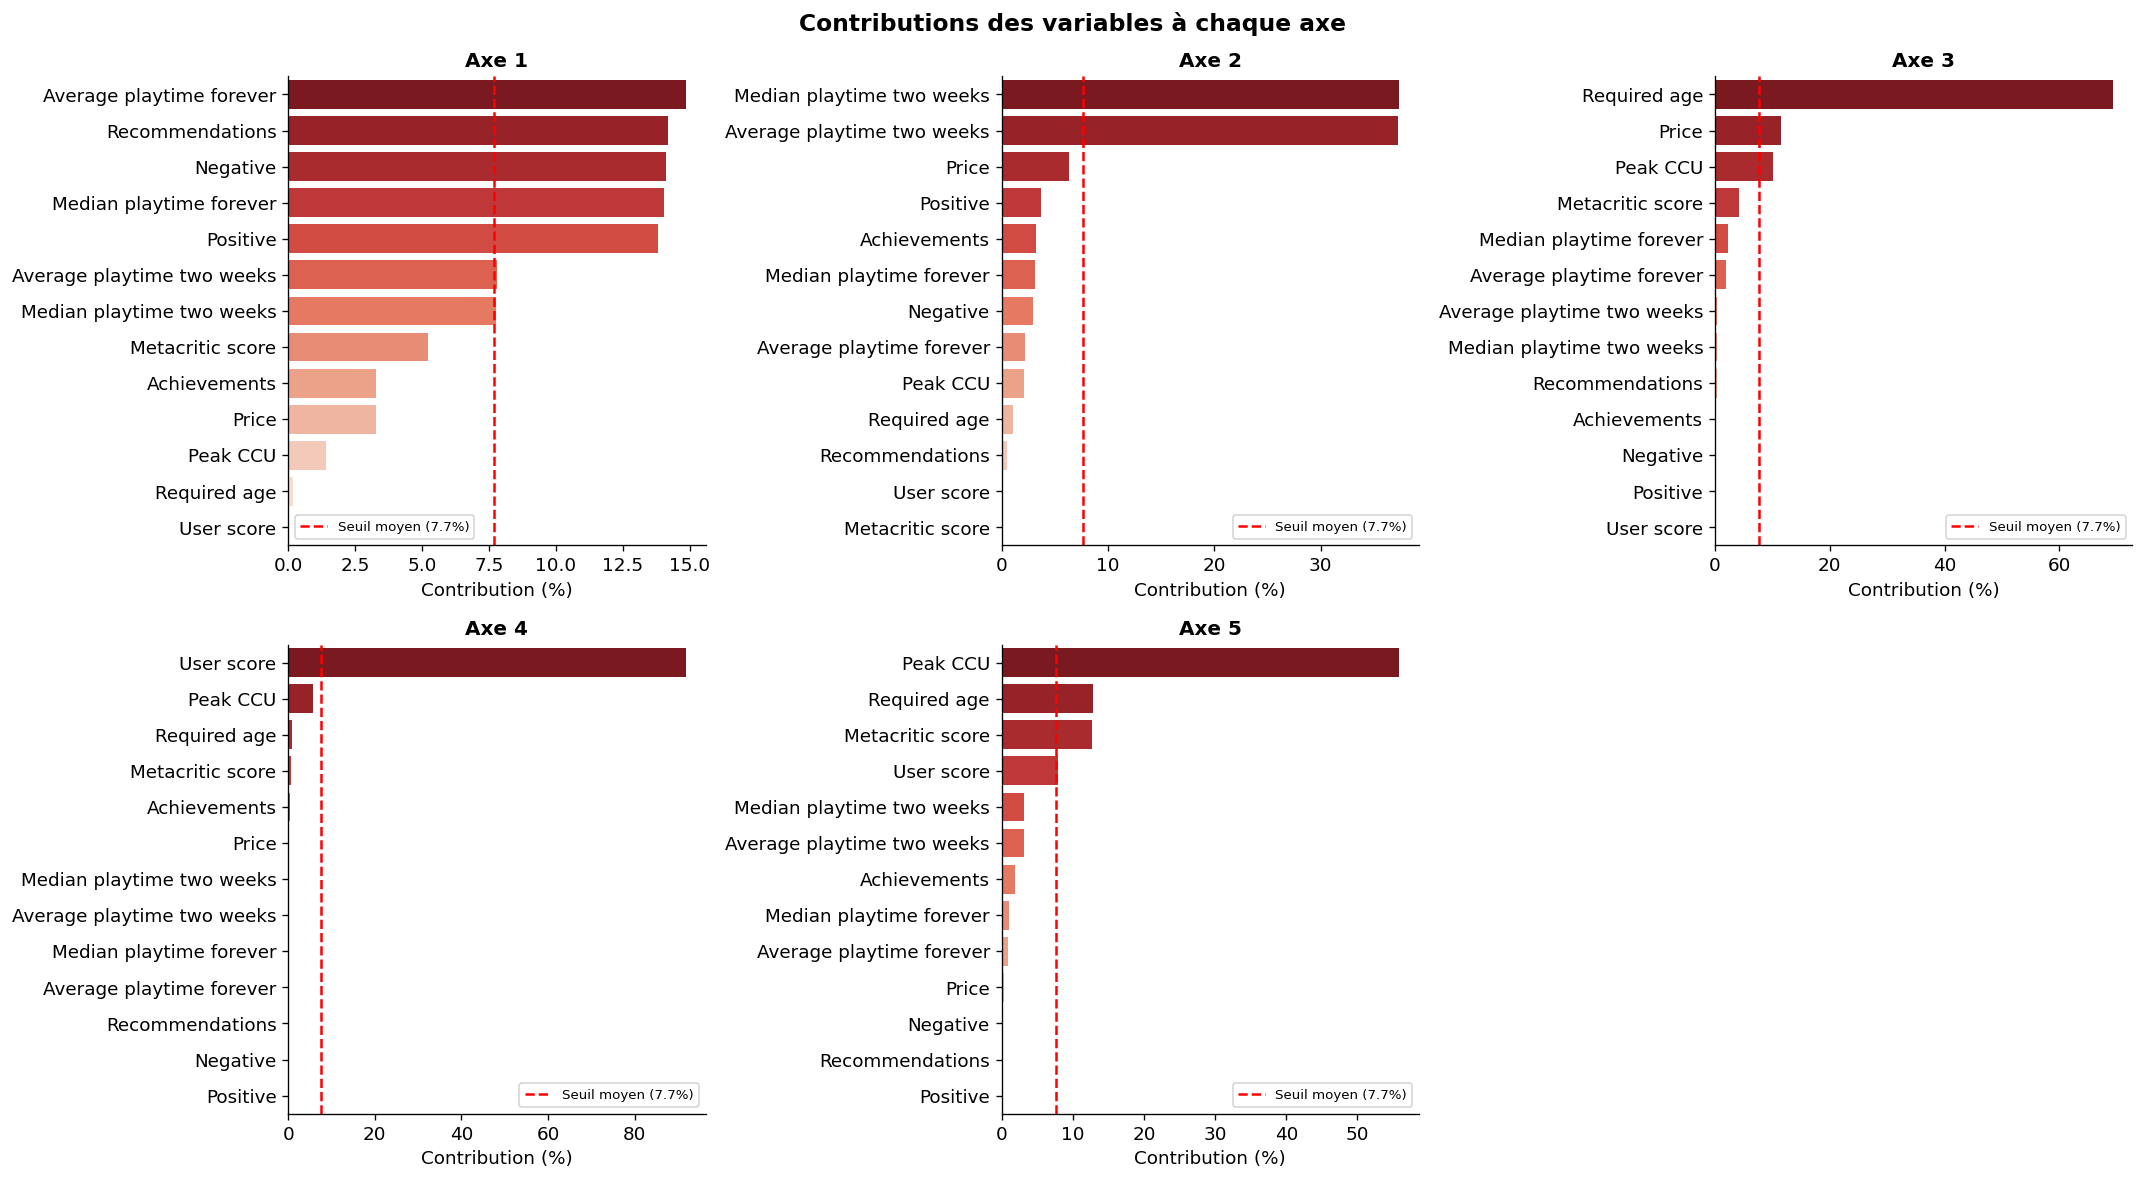

In [10]:
contributions = (cos2 / cos2.sum(axis=0)) * 100
seuil_contrib = 100 / len(cols_quanti_pca)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(5):
    df_c = pd.DataFrame({'Variable': cols_quanti_pca,
                         'Contribution': contributions[:, i]}).sort_values('Contribution', ascending=False)
    sns.barplot(data=df_c, x='Contribution', y='Variable', palette='Reds_r', ax=axes[i])
    axes[i].axvline(seuil_contrib, color='red', linestyle='--',
                    label=f'Seuil moyen ({seuil_contrib:.1f}%)')
    axes[i].set_title(f"Axe {i+1}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Contribution (%)"); axes[i].set_ylabel("")
    axes[i].legend(fontsize=8)

fig.delaxes(axes[5])
plt.suptitle("Contributions des variables à chaque axe", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Lecture :** La ligne rouge pointillée indique le seuil au-delà duquel la contribution d'une variable est supérieure à la moyenne. L'analyse de ces contributions révèle que l'Axe 1 est principalement défini par les métriques de popularité. De son côté, l'Axe 2 est très nettement dominé par le temps de jeu récent. Enfin, l'Axe 3 s'articule autour du prix et des contenus additionnels (DLC), reflétant ainsi la stratégie commerciale des jeux.


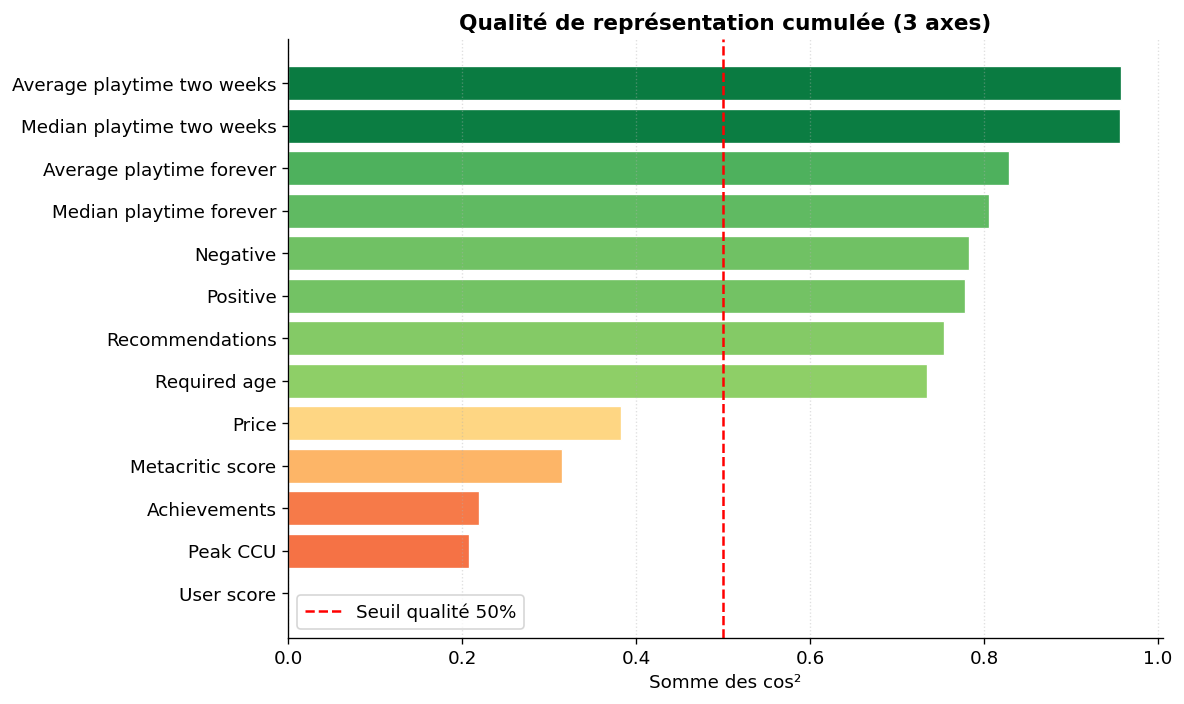

In [11]:
# Qualité de représentation cumulée sur n_axes retenus
var_cos2_sum = cos2[:, :n_axes].sum(axis=1)
df_cos2 = pd.DataFrame({'Variable': cols_quanti_pca, 'Cos2_Total': var_cos2_sum}).sort_values('Cos2_Total')

plt.figure(figsize=(10, 6))
colors_bar = plt.cm.RdYlGn(df_cos2['Cos2_Total'])
plt.barh(df_cos2['Variable'], df_cos2['Cos2_Total'],
         color=colors_bar, edgecolor='white', linewidth=0.8)
plt.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Seuil qualité 50%')
plt.title(f"Qualité de représentation cumulée ({n_axes} axes)", fontsize=13, fontweight='bold')
plt.xlabel("Somme des cos²")
plt.legend()
plt.grid(axis='x', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


**Lecture :** La majorité des variables dépassent le seuil des 50 % de représentation, ce qui prouve que le modèle factoriel les décrit avec une grande fiabilité. À l'inverse, le score Metacritic, les succès, le pic de joueurs et le prix se situent nettement en deçà de ce seuil. Cela confirme que ces quatres métriques sont secondaires et ne suffisent pas à structurer les grandes dynamiques de popularité du marché.

### 5.4 Nuage des Individus


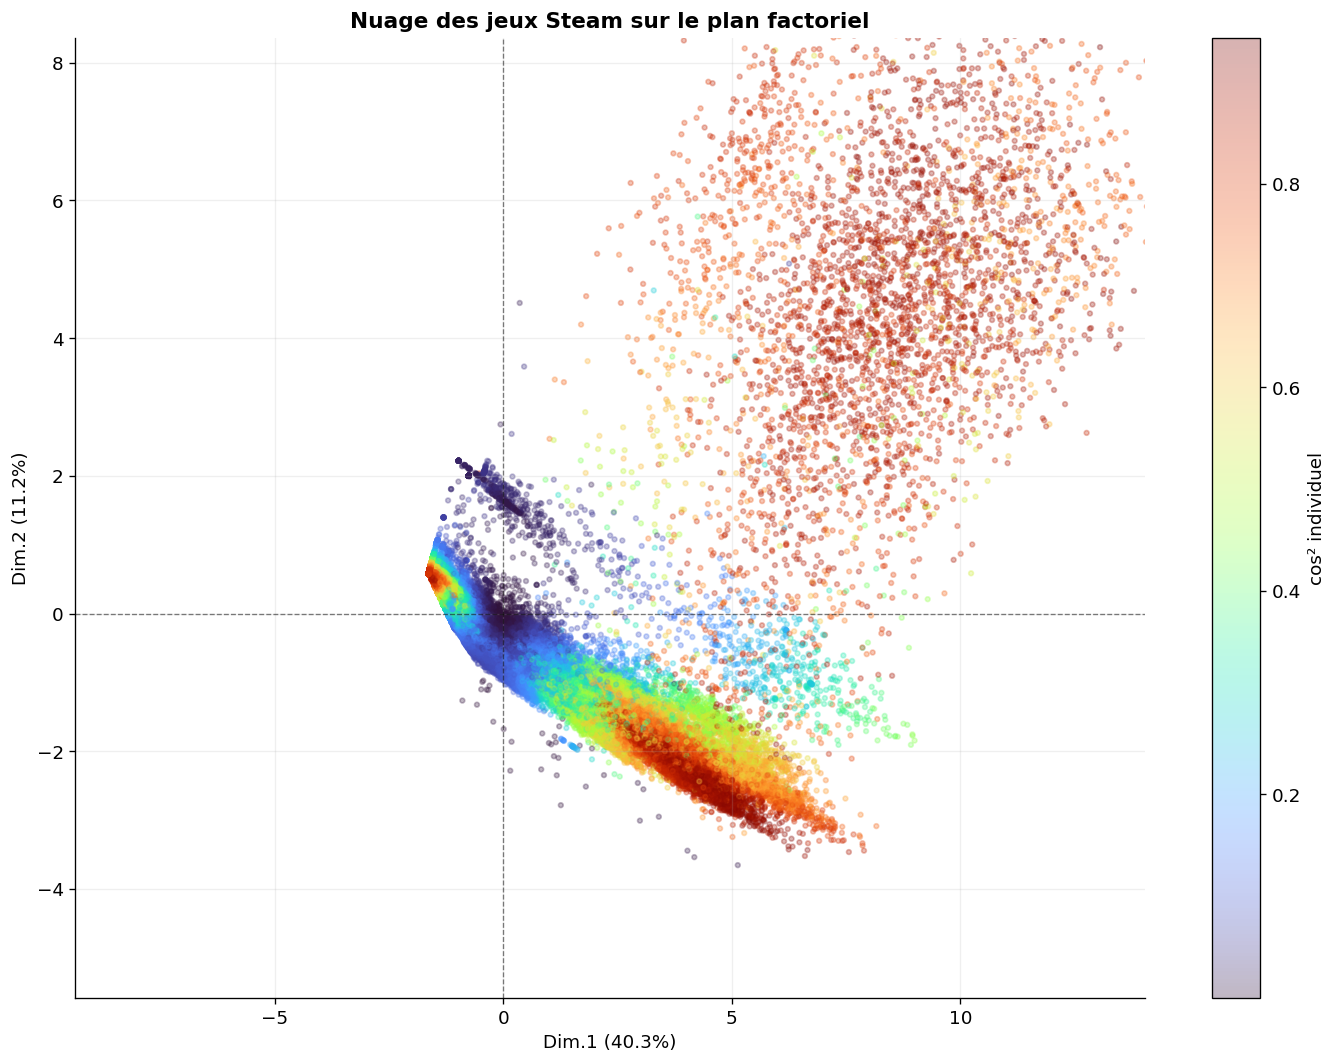

In [12]:
ind_coords  = pca_data[:, :2]
ind_dist2   = (data_scaled**2).sum(axis=1)
cos2_ind    = (ind_coords**2).sum(axis=1) / ind_dist2

x_lim = np.percentile(np.abs(ind_coords[:, 0]), 99)
y_lim = np.percentile(np.abs(ind_coords[:, 1]), 99)

plt.figure(figsize=(12, 9))
sc = plt.scatter(ind_coords[:, 0], ind_coords[:, 1],
                 c=cos2_ind, cmap='turbo', alpha=0.3, s=8)
plt.xlim(-x_lim, x_lim * 1.5); plt.ylim(-y_lim, y_lim * 1.5)
plt.colorbar(sc, label='cos² individuel')
plt.axhline(0, color='black', linestyle='--', lw=0.8, alpha=0.5)
plt.axvline(0, color='black', linestyle='--', lw=0.8, alpha=0.5)
plt.xlabel(f"Dim.1 ({variance_ratio[0]:.1f}%)", fontsize=11)
plt.ylabel(f"Dim.2 ({variance_ratio[1]:.1f}%)", fontsize=11)
plt.title("Nuage des jeux Steam sur le plan factoriel", fontsize=13, fontweight='bold')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


**Lecture :** La répartition des jeux dessine une forme de "comète" caractéristique du marché. À l'origine se concentre une masse dense de titres sans audience, faiblement représentés par le modèle. À l'inverse, les points qui s'étirent vers la droite et le haut mettent en évidence les succès commerciaux et les jeux hautement engageants, dont les dynamiques sont parfaitement capturées par ces deux premiers axes factoriels.


---
## 6. Clustering

On cherche à partitionner les jeux en groupes homogènes. Deux méthodes complémentaires sont utilisées : K-Means et CAH Ward pour valider la structure.

### 6.1 Choix du Nombre de Clusters


k=2 | Inertie=469044 | Silhouette=0.6907
k=3 | Inertie=260874 | Silhouette=0.6899
k=4 | Inertie=217764 | Silhouette=0.6980
k=5 | Inertie=161329 | Silhouette=0.4970
k=6 | Inertie=133890 | Silhouette=0.4474
k=7 | Inertie=119311 | Silhouette=0.4434
k=8 | Inertie=106666 | Silhouette=0.4393


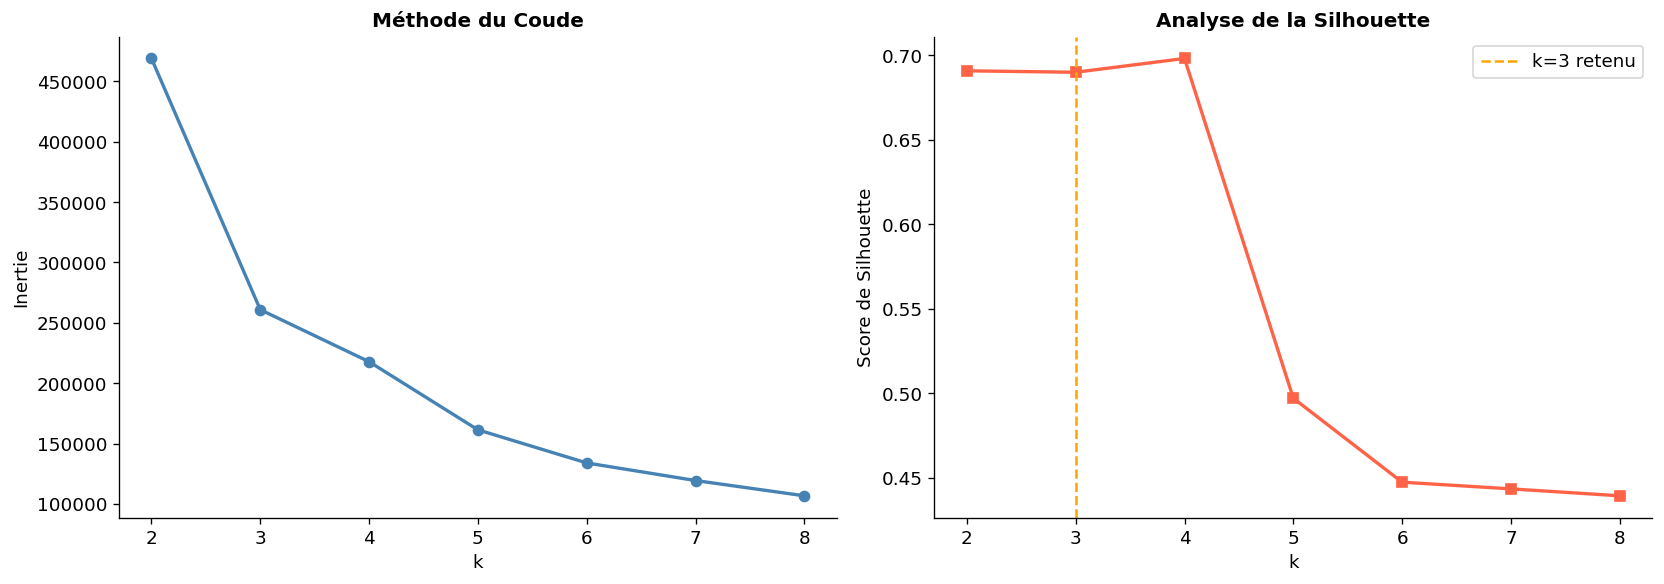

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pca_features = pca_data[:, :n_axes]

np.random.seed(42)
idx_s = np.random.choice(len(pca_features), min(10000, len(pca_features)), replace=False)
sample_s = pca_features[idx_s]

inertias, silhouettes = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_features)
    inertias.append(km.inertia_)
    labels_s = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(sample_s)
    silhouettes.append(silhouette_score(sample_s, labels_s))
    print(f"k={k} | Inertie={inertias[-1]:.0f} | Silhouette={silhouettes[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(k_range, inertias, 'o-', color='steelblue', linewidth=2)
ax1.set_xlabel("k"); ax1.set_ylabel("Inertie")
ax1.set_title("Méthode du Coude", fontsize=12, fontweight='bold')

ax2.plot(k_range, silhouettes, 's-', color='tomato', linewidth=2)
ax2.axvline(3, color='orange', linestyle='--', label='k=3 retenu')
ax2.set_xlabel("k"); ax2.set_ylabel("Score de Silhouette")
ax2.set_title("Analyse de la Silhouette", fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()


**Lecture :** La méthode du coude (gauche) ne montre pas de rupture franche mais une inflexion autour de k=3. La silhouette (droite) confirme que k=3 offre un bon compromis entre séparation des clusters et interprétabilité (score silhouette et inertie) alors que k=2 sépare trop grossièrement et k=4 présente une silhouette légèrement supérieure (0.698 vs 0.690), mais le gain est marginal (+0.008) et le 4ème cluster produit une partition difficile à interpréter qualitativement.


### 6.2 Silhouette Plots Détaillés


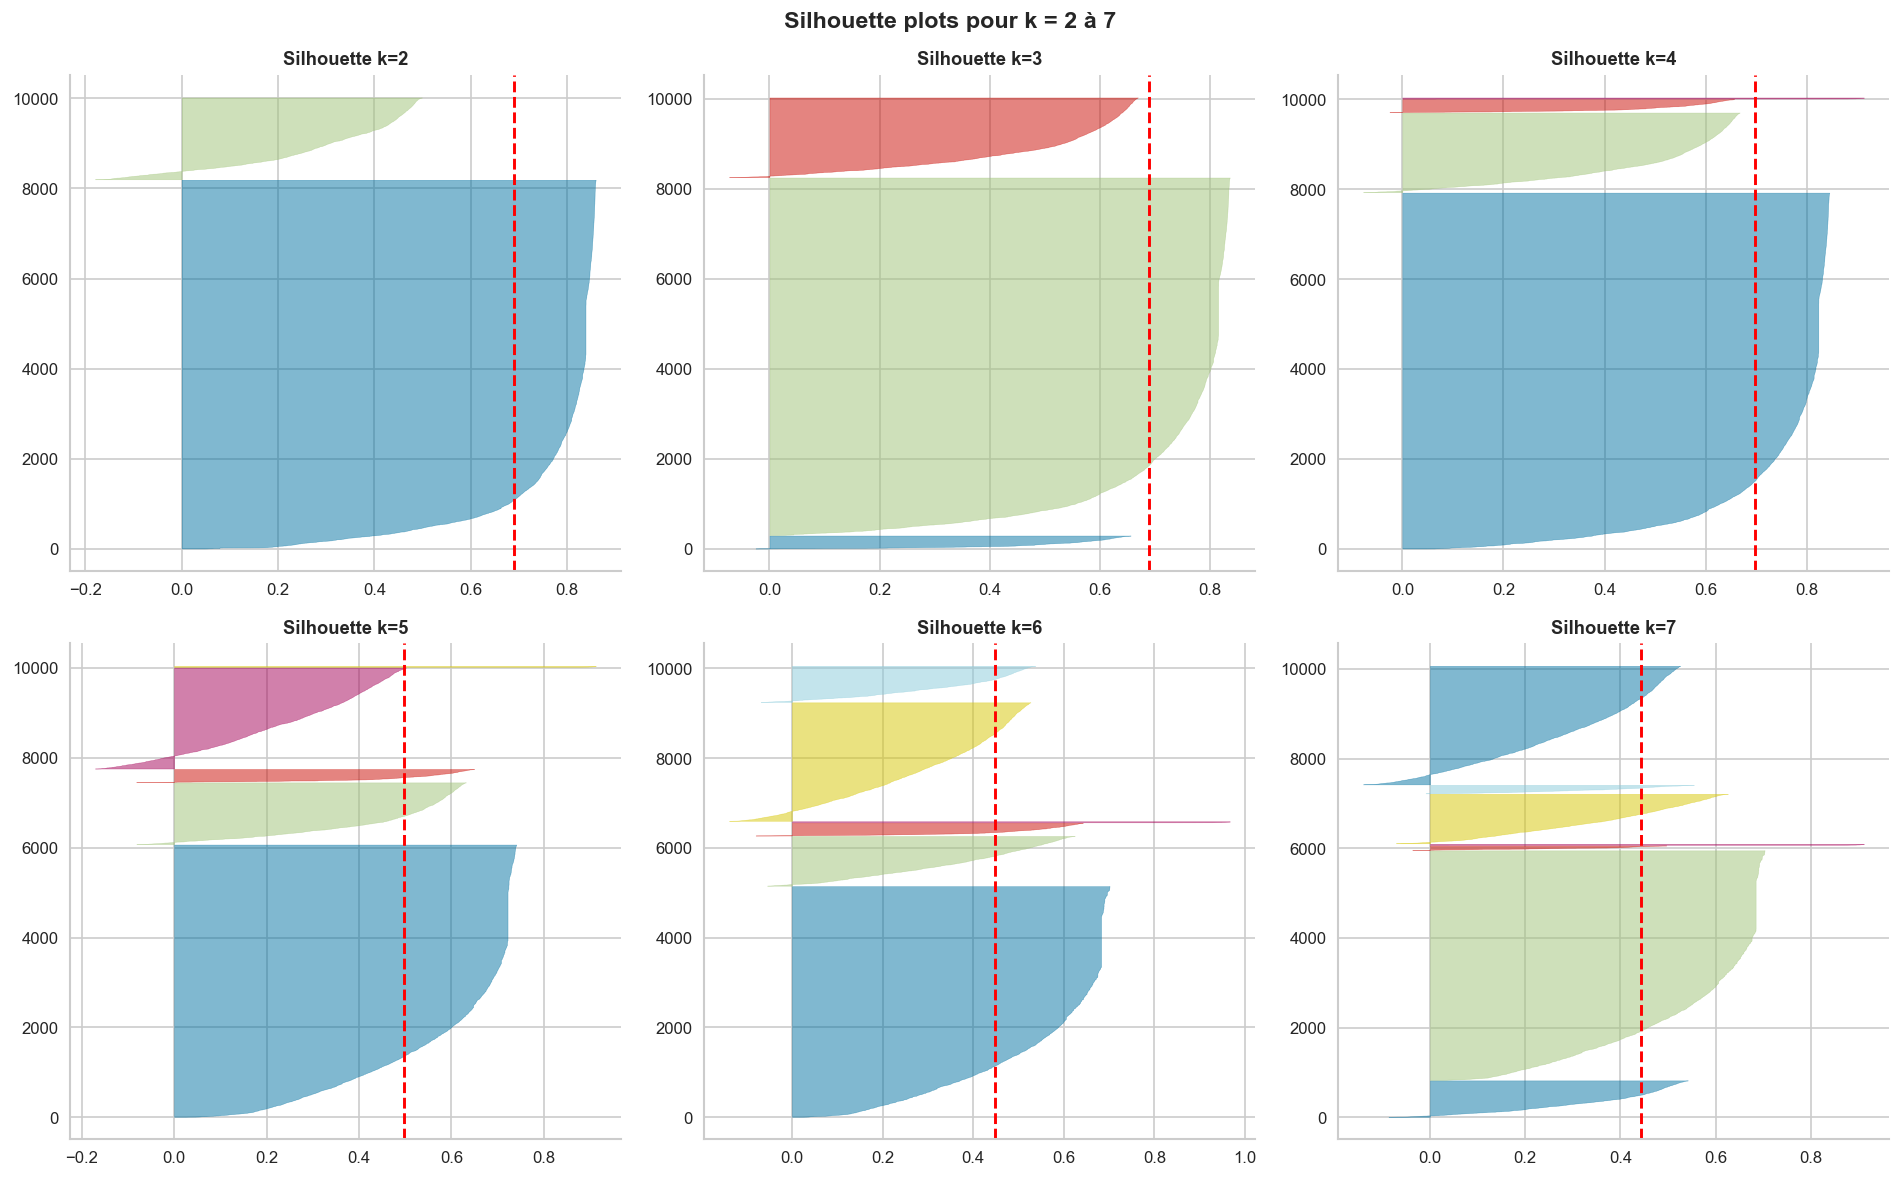

In [14]:
from yellowbrick.cluster import SilhouetteVisualizer

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for idx, k in enumerate(range(2, 8)):
    km_viz = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    viz = SilhouetteVisualizer(km_viz, colors='yellowbrick', ax=axes[idx], force_model=True)
    viz.fit(sample_s)
    axes[idx].set_title(f"Silhouette k={k}", fontsize=11, fontweight='bold')
plt.suptitle("Silhouette plots pour k = 2 à 7", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



**Lecture :** Chaque graphe montre la distribution des scores de silhouette par cluster. Un profil idéal présente des barres larges, uniformes et toutes positives. Pour k=3, les profils restent globalement positifs avec un gros cluster dominant (la masse), confirmant la structure asymétrique du marché.


### 6.3 K-Means (k=3) : Visualisation


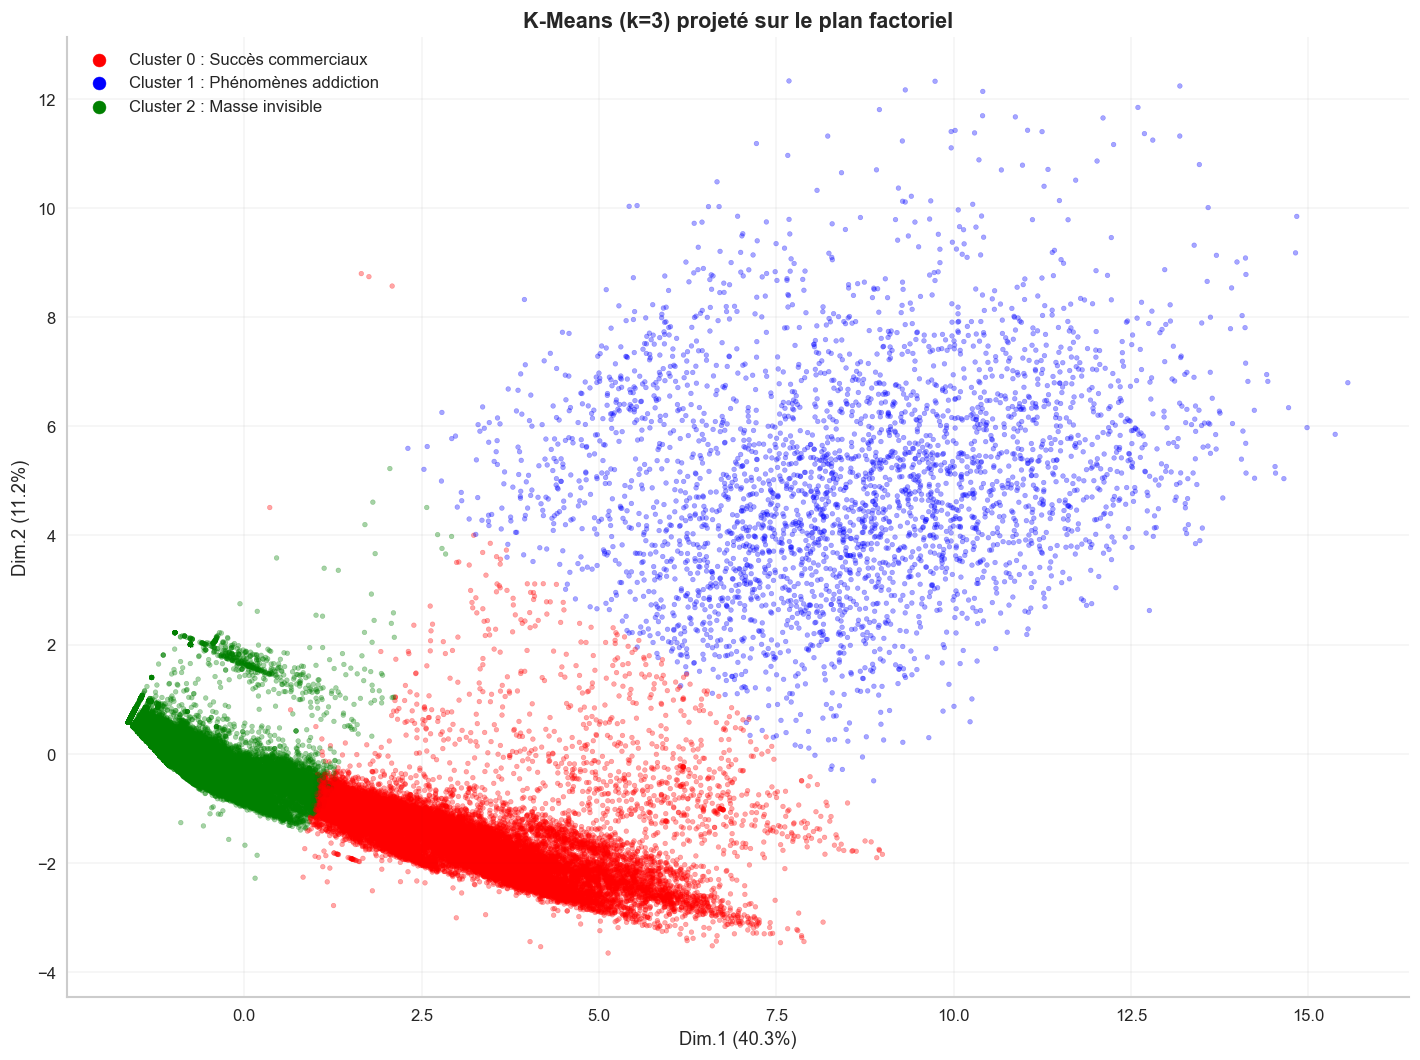

In [15]:
from matplotlib.colors import ListedColormap

k_opt    = 3
kmeans   = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_features)
df['Cluster'] = clusters

cluster_names = {0: 'Succès commerciaux',  1: 'Phénomènes addiction', 2: 'Masse invisible'}
df['Cluster_label'] = df['Cluster'].map(cluster_names)

colors = ListedColormap(['red', 'blue', 'green'])

plt.figure(figsize=(12, 9))
sc = plt.scatter(pca_data[:, 0], pca_data[:, 1],
                 c=clusters, cmap=colors, alpha=0.35, s=8)

plt.xlabel(f"Dim.1 ({variance_ratio[0]:.1f}%)", fontsize=11)
plt.ylabel(f"Dim.2 ({variance_ratio[1]:.1f}%)", fontsize=11)
plt.title(f"K-Means (k={k_opt}) projeté sur le plan factoriel", fontsize=13, fontweight='bold')

handles = [plt.scatter([], [], c=c, s=60, label=f"Cluster {k} : {v}")
           for k, (c, v) in enumerate(zip(['red','blue','green'], cluster_names.values()))]

plt.legend(handles=handles, fontsize=10, loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


**Lecture :** La projection du K-Means sur les deux premiers axes factoriels confirme visuellement les trois grands profils du marché. À l'origine se concentre la masse invisible, regroupant la majorité des titres sans audience ni engagement. Le groupe qui s'étire horizontalement le long de l'Axe 1 rassemble les succès commerciaux, caractérisés par une forte notoriété mais un temps de jeu standard et le nuage qui s'élève vers le haut et la droite isole les phénomènes d'addiction.


### 6.4 Validation par CAH (Classification Ascendante Hiérarchique)


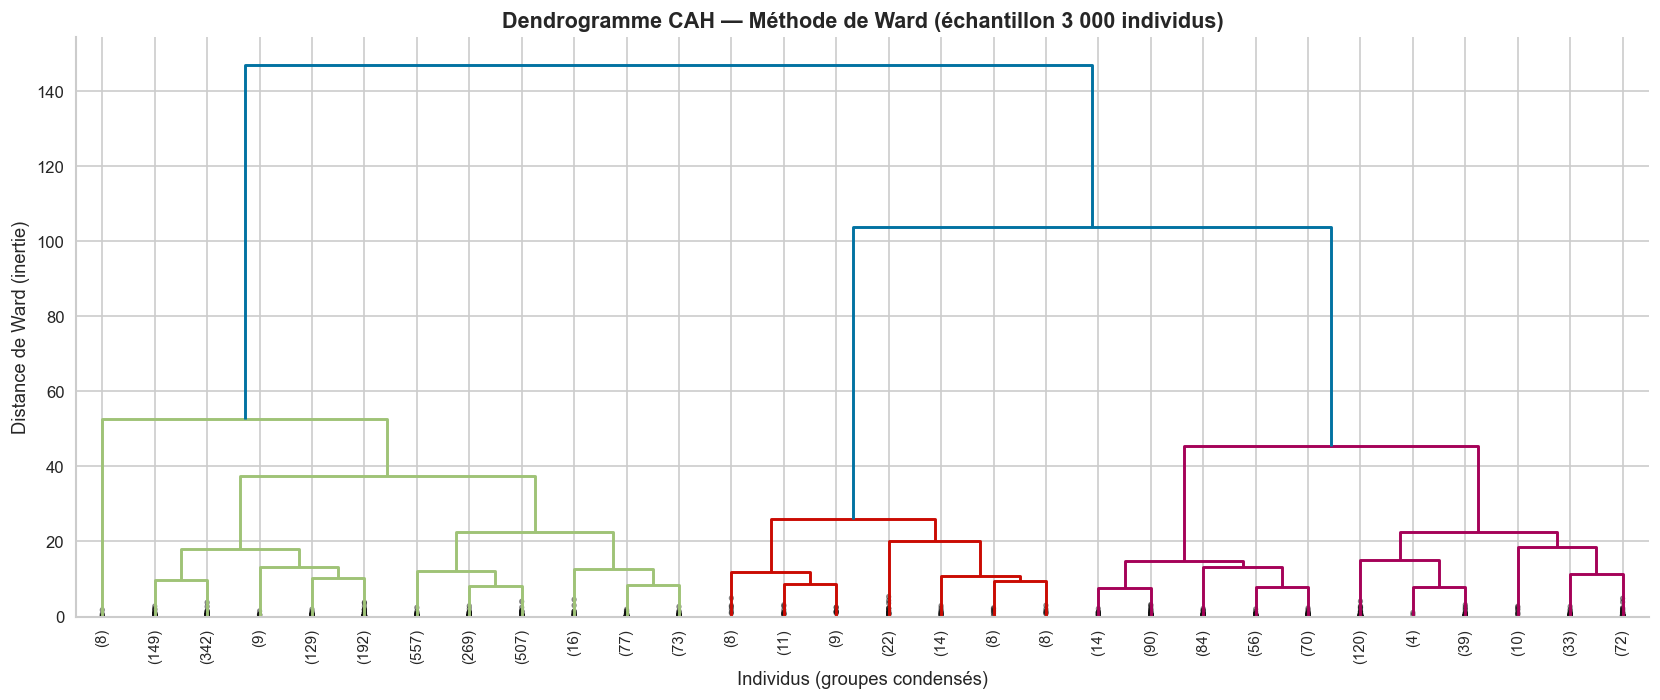

Silhouette CAH  (k=3) : 0.6699
Silhouette KMeans (k=3) : 0.6899


In [16]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

np.random.seed(42)
idx_cah  = np.random.choice(len(pca_features), min(3000, len(pca_features)), replace=False)
sample_c = pca_features[idx_cah]

Z = linkage(sample_c, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=9, show_contracted=True)
plt.title("Dendrogramme CAH — Méthode de Ward (échantillon 3 000 individus)",
          fontsize=13, fontweight='bold')
plt.xlabel("Individus (groupes condensés)")
plt.ylabel("Distance de Ward (inertie)")
plt.tight_layout()
plt.show()

labels_cah = fcluster(Z, t=k_opt, criterion='maxclust')
sil_cah = silhouette_score(sample_c, labels_cah)
sil_km  = silhouette_score(sample_s, KMeans(n_clusters=k_opt, random_state=42, n_init=10).fit_predict(sample_s))
print(f"Silhouette CAH  (k=3) : {sil_cah:.4f}")
print(f"Silhouette KMeans (k=3) : {sil_km:.4f}")


**Lecture :** Le dendrogramme montre une coupure naturelle à k=3 (trois branches majeures). La comparaison des scores de silhouette entre K-Means et CAH valide la cohérence de la segmentation : les deux méthodes convergent vers la même structure, ce qui renforce la robustesse des clusters identifiés.


### 6.5 Caractérisation des Clusters


In [17]:
cols_quanti_pca_used = [c for c in cols_quanti_pca if c in df.columns]
stats_cl = df.groupby('Cluster')[cols_quanti_pca_used].mean()
stats_cl['Nb_Jeux'] = df.groupby('Cluster').size()
stats_cl.index = [f"Cluster {i} — {cluster_names[i]}" for i in stats_cl.index]

print("Moyennes par cluster :")
display(stats_cl.style.background_gradient(cmap='YlGn', axis=0)
                      .format(precision=2))


Moyennes par cluster :


,Peak CCU,Required age,Price,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Nb_Jeux
Cluster 0 — Succès commerciaux,0.39,5.78,36.80,10.14,0.10,1035.93,219.94,48.15,1207.14,605.71,0.14,574.46,0.14,21143
Cluster 1 — Phénomènes addiction,2.11,9.91,41.80,26.29,0.01,31049.00,4657.28,46.53,27000.19,3724.33,500.43,2668.27,534.34,3372
Cluster 2 — Masse invisible,0.05,4.37,13.57,0.12,0.01,15.57,3.99,10.63,13.90,1.44,0.00,1.41,0.00,98096


**Lecture :** Ce tableau confirme la forte hiérarchisation du marché en trois strates distinctes. La Masse invisible regroupe l'écrasante majorité du catalogue (près de 98 000 jeux) mais affiche des métriques d'engagement et de popularité quasi nulles : c'est la longue traîne de Steam. Les Succès commerciaux forment une classe intermédiaire performante : ces titres (environ 21 000) génèrent des volumes d'avis et des revenus solides, mais leur rétention s'essouffle vite (temps de jeu récent proche de zéro). Enfin, les Phénomènes d'addiction constituent l'élite absolue de la plateforme (à peine 3 300 jeux). Loin d'avoir une notoriété modeste, ils surperforment sur l'ensemble des métriques : ils cumulent à la fois une popularité colossale (plus de 30 000 avis positifs en moyenne) et des temps de jeu titanesques, s'imposant comme les véritables leaders du marché.


In [18]:
# Parangons — jeux les plus proches du centroïde de chaque cluster
from sklearn.metrics import pairwise_distances

df_src = pd.read_csv('games.csv', usecols=['AppID', 'Name'], index_col=None).set_index(df.index[:len(df)])

print("=" * 60)
print("PARANGONS PAR CLUSTER (jeux les plus représentatifs)")
print("=" * 60)
for i in range(k_opt):
    idx_c  = np.where(clusters == i)[0]
    pts_c  = pca_features[idx_c]
    dist_c = pairwise_distances(pts_c, kmeans.cluster_centers_[i:i+1]).flatten()
    top5   = idx_c[np.argsort(dist_c)[:5]]
    subset = df.iloc[top5][['Cluster_label'] + [c for c in ['Positive','Peak CCU','Price'] if c in df.columns]].copy()
    if 'Name' in pd.read_csv('games.csv', nrows=1).columns:
        names = pd.read_csv('games.csv', usecols=['Name']).iloc[top5]['Name'].values
        subset.insert(0, 'Name', names)
    print(f"\n--- Cluster {i} : {cluster_names[i]} ---")
    print(subset.to_string())


PARANGONS PAR CLUSTER (jeux les plus représentatifs)

--- Cluster 0 : Succès commerciaux ---
                 Name       Cluster_label  Positive  Peak CCU  Price
367570    Jul 6, 2015  Succès commerciaux       853         0     22
1794780  Nov 29, 2021  Succès commerciaux       510         0     40
361670   Apr 28, 2015  Succès commerciaux       390         0     50
1788850  Jul 14, 2022  Succès commerciaux       351         0     50
1644150  Jul 29, 2021  Succès commerciaux       478         0     50

--- Cluster 1 : Phénomènes addiction ---
                 Name         Cluster_label  Positive  Peak CCU  Price
2305840   Aug 8, 2024  Phénomènes addiction      2604         0      0
742300    Oct 2, 2018  Phénomènes addiction      4106         0     85
1515210   Nov 2, 2022  Phénomènes addiction     14362         0     44
418180   Aug 22, 2016  Phénomènes addiction      1756         0      0
1250760  Aug 17, 2021  Phénomènes addiction      7173         0     55

--- Cluster 2 : Masse in

*Les parangons sont les jeux mathématiquement les plus proches du centroïde de leur cluster — ils en constituent les représentants les plus "typiques".*


---
## 7. Analyse en Composantes Multiples (ACM)



In [19]:
import prince

df['Genres']     = df['Genres'].fillna('').astype(str)
df['Categories'] = df['Categories'].fillna('').astype(str)

genres_dum  = df['Genres'].str.get_dummies(sep=',')
categ_dum   = df['Categories'].str.get_dummies(sep=',')

top_gen  = genres_dum.sum().sort_values(ascending=False).head(15).index
top_cat  = categ_dum.sum().sort_values(ascending=False).head(15).index

df['Prix_Gratuit'] = (df['Price'] == 0).astype(int)
df['Prix_Premium'] = (df['Price'] > 30).astype(int)

df_qual = pd.concat([genres_dum[top_gen], categ_dum[top_cat],
                     df[['Prix_Gratuit', 'Prix_Premium']]], axis=1)

mask_qual = df_qual.astype(int).sum(axis=1) > 0
df_qual   = df_qual[mask_qual]

mca = prince.MCA(n_components=5, n_iter=10, random_state=42)
mca.fit(df_qual.astype(bool))

print(mca.eigenvalues_summary)


          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.132        13.16%                     13.16%
1              0.105        10.53%                     23.69%
2              0.064         6.38%                     30.07%
3              0.055         5.49%                     35.56%
4              0.050         4.99%                     40.56%


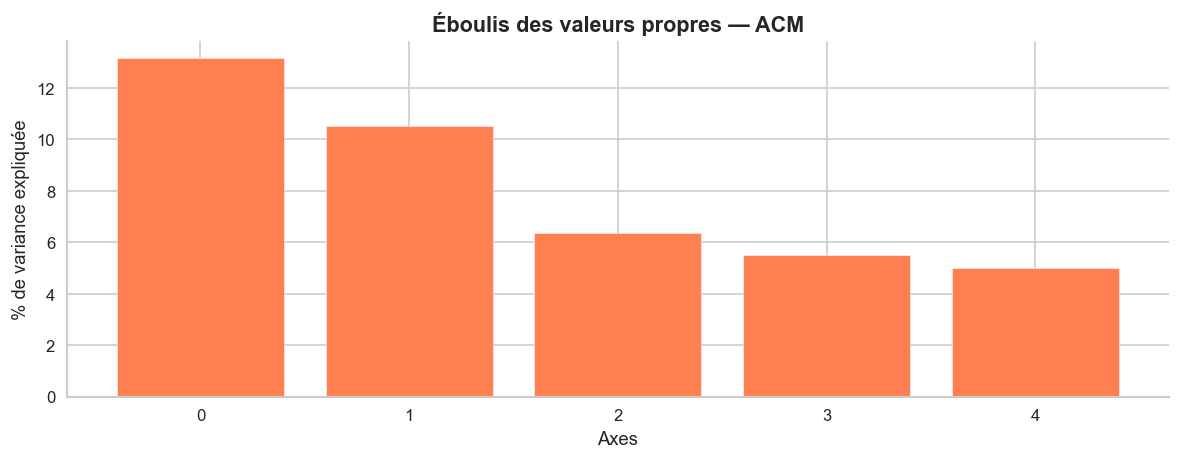

In [20]:
# Éboulis ACM
summary_mca = mca.eigenvalues_summary
variances_propres = summary_mca['% of variance'].astype(str).str.replace('%', '').astype(float)
plt.figure(figsize=(10, 4))
plt.bar(summary_mca.index, variances_propres, color='coral', edgecolor='white')
plt.title("Éboulis des valeurs propres — ACM", fontsize=13, fontweight='bold')
plt.xlabel("Axes")
plt.ylabel("% de variance expliquée")
plt.tight_layout()
plt.show()


**Lecture :** L'éboulis des valeurs propres révèle une décroissance marquée avec un coude bien visible après le deuxième axe. Les Axes 0 et 1 se détachent nettement et concentrent à eux seuls près d'un quart de l'information totale. À partir de l'Axe 2, le gain de variance chute drastiquement et stagne autour de 5 à 6 %. Cette structure confirme que l'essentiel des dynamiques majeures de notre jeu de données est résumé par ces deux premières dimensions, justifiant de concentrer notre analyse sur ce premier plan factoriel.


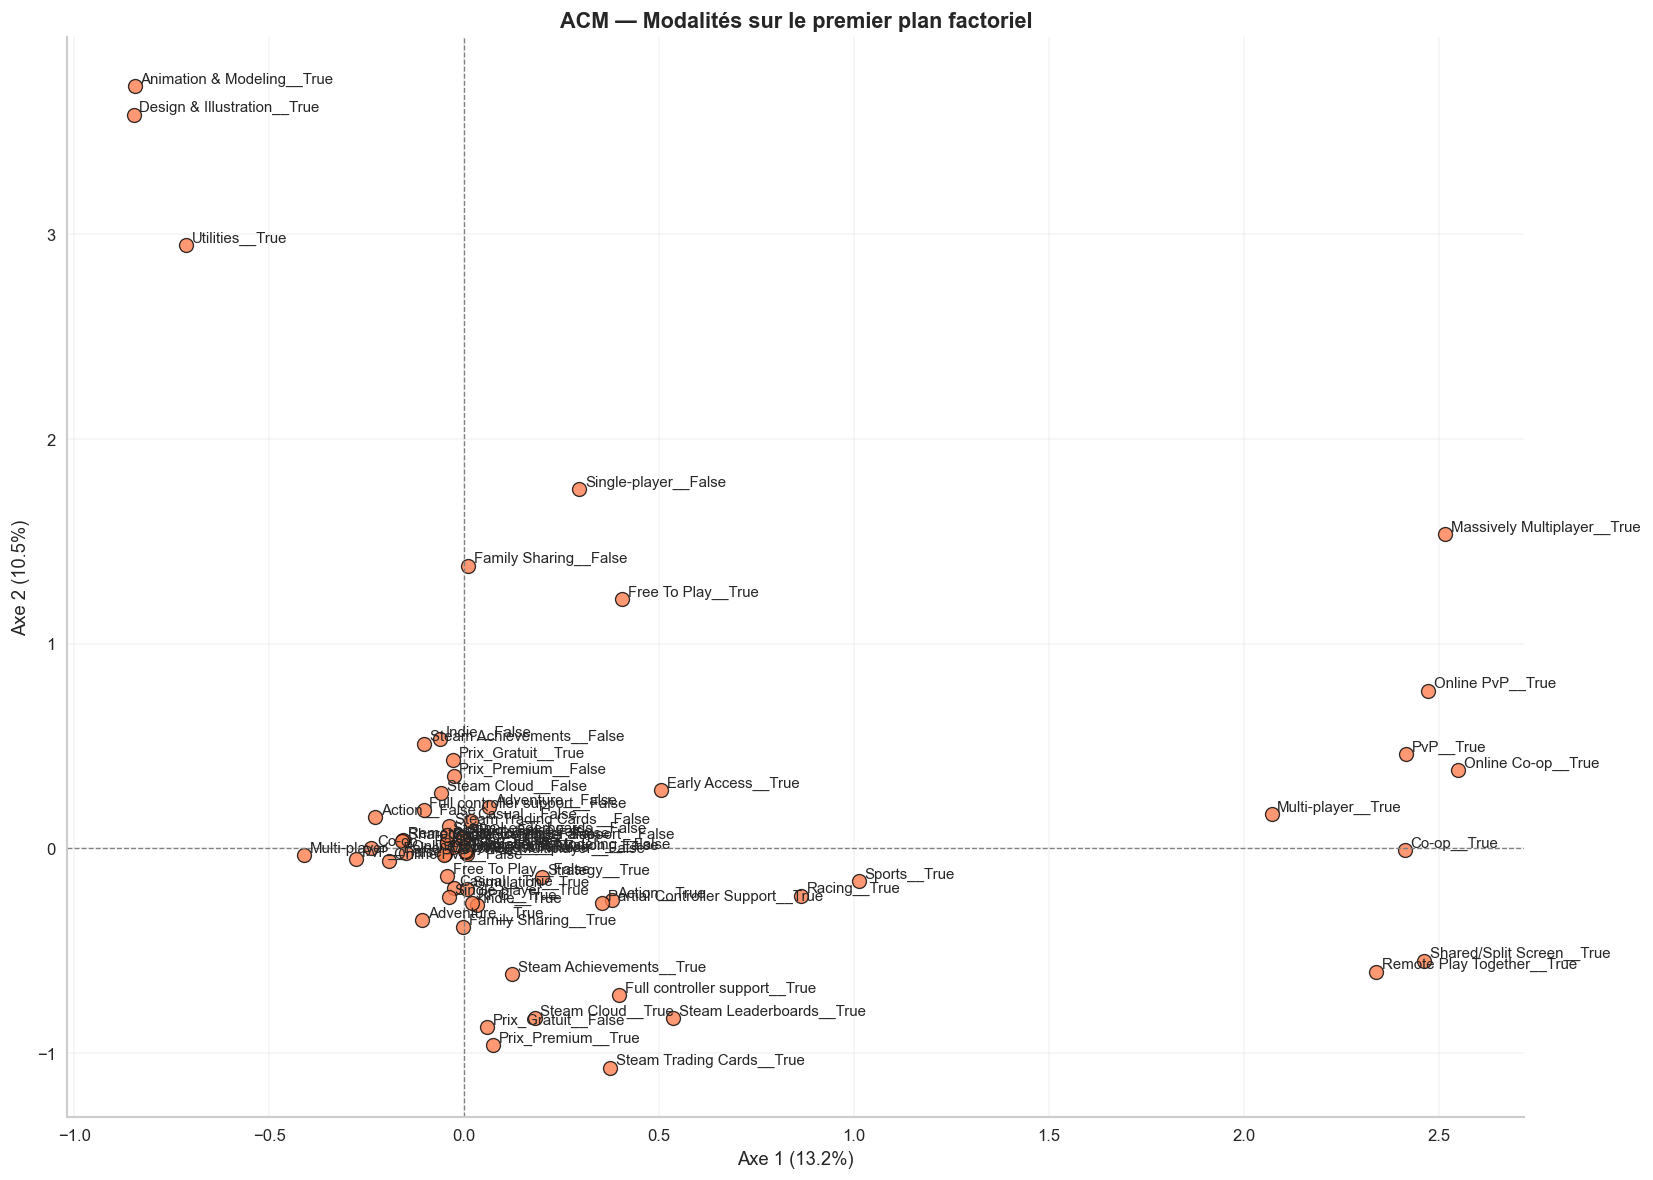

In [21]:
# Projection des modalités (plan 1-2)
col_coords_mca = mca.column_coordinates(df_qual.astype(bool))

plt.figure(figsize=(14, 10))
plt.scatter(col_coords_mca[0], col_coords_mca[1],
            color='coral', s=70, edgecolors='black', alpha=0.8, linewidths=0.8)
for i, txt in enumerate(col_coords_mca.index):
    plt.annotate(txt, (col_coords_mca.iloc[i, 0]+0.015, col_coords_mca.iloc[i, 1]+0.015), fontsize=9)

plt.axhline(0, color='gray', linestyle='--', lw=0.8)
plt.axvline(0, color='gray', linestyle='--', lw=0.8)
plt.title("ACM — Modalités sur le premier plan factoriel", fontsize=13, fontweight='bold')
plt.xlabel(f"Axe 1 ({float(str(summary_mca['% of variance'].iloc[0]).replace('%', '')):.1f}%)", fontsize=11)
plt.ylabel(f"Axe 2 ({float(str(summary_mca['% of variance'].iloc[1]).replace('%', '')):.1f}%)", fontsize=11)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


**Lecture :** Les modalités proches sur ce graphe sont fréquemment co-présentes dans les mêmes jeux. On distingue les genres liés au multijoueur (haut) des jeux solo (bas), et les genres populaires/commerciaux (droite) de la niche indépendante (gauche).


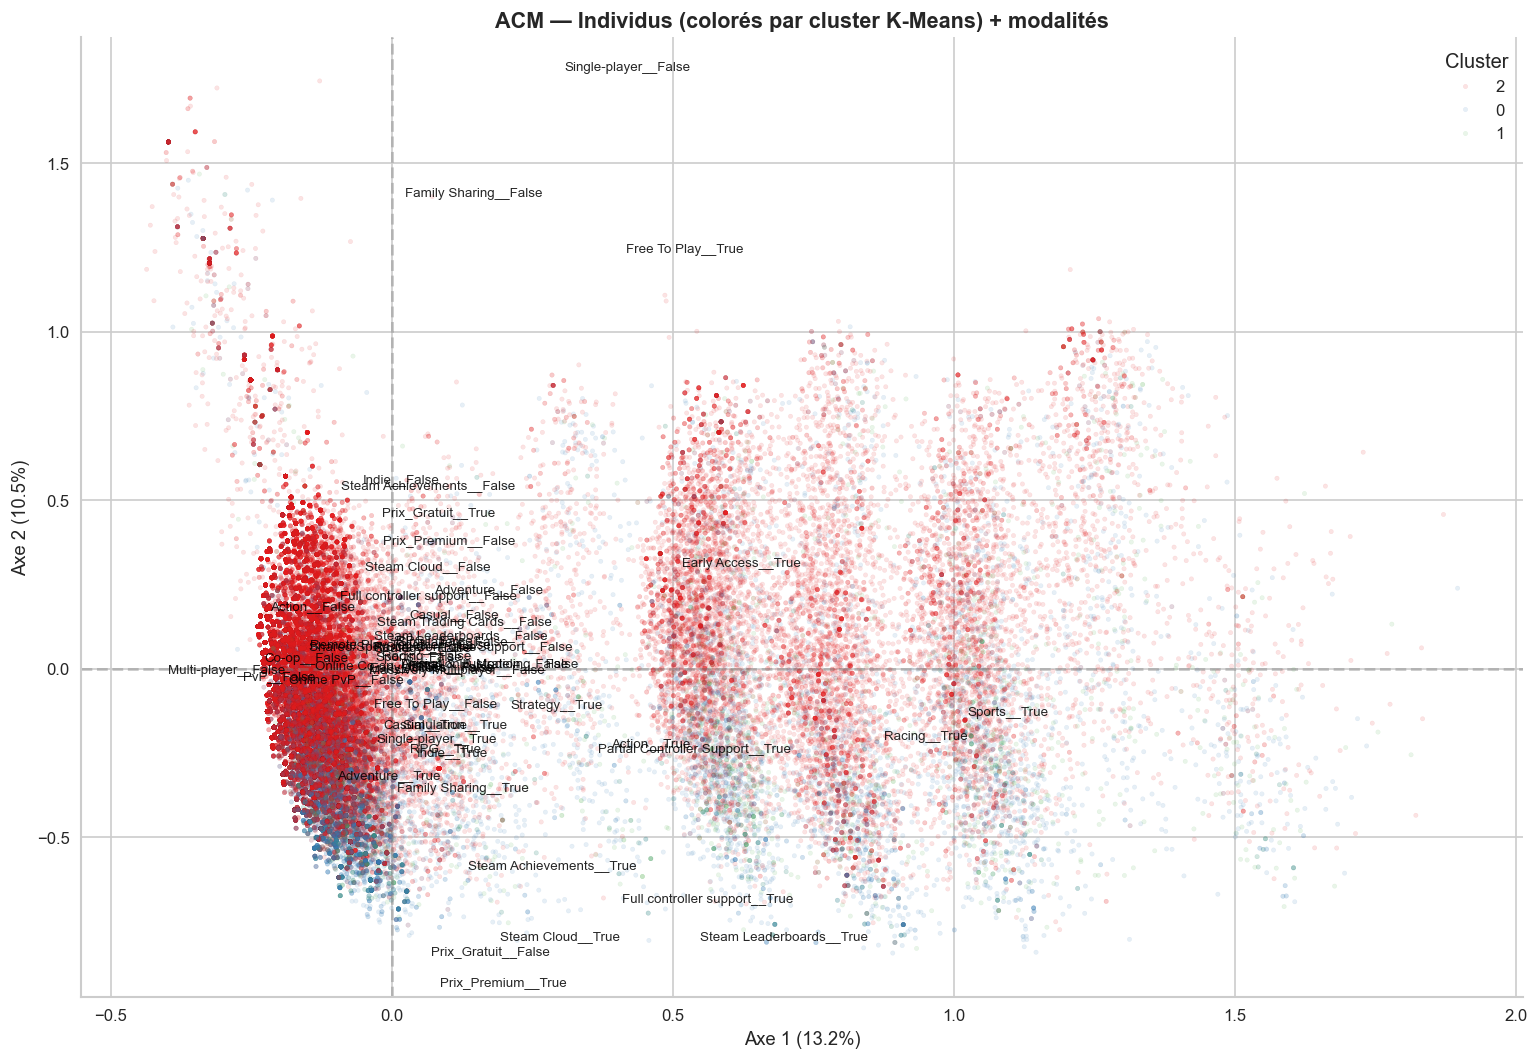

In [22]:
# Individus colorés par cluster K-Means superposés aux modalités
ind_mca = mca.row_coordinates(df_qual.astype(bool))
ind_mca['Cluster'] = df.loc[df_qual.index, 'Cluster'].astype(str)

plt.figure(figsize=(13, 9))
sns.scatterplot(x=0, y=1, hue='Cluster', data=ind_mca,
                palette='Set1', alpha=0.12, s=7, edgecolor=None)
for i, txt in enumerate(col_coords_mca.index):
    plt.annotate(txt, (col_coords_mca.iloc[i,0], col_coords_mca.iloc[i,1]),
                 fontsize=8, color='black', alpha=0.85,
                 xytext=(4, 4), textcoords='offset points')

plt.axhline(0, color='gray', linestyle='--', alpha=0.4)
plt.axvline(0, color='gray', linestyle='--', alpha=0.4)
plt.title("ACM — Individus (colorés par cluster K-Means) + modalités", fontsize=13, fontweight='bold')
plt.xlabel(f"Axe 1 ({float(str(summary_mca['% of variance'].iloc[0]).replace('%', '')):.1f}%)")
plt.ylabel(f"Axe 2 ({float(str(summary_mca['% of variance'].iloc[1]).replace('%', '')):.1f}%)")
plt.tight_layout()
plt.show()


**Lecture :** La projection des clusters K-Means (issus des variables quantitatives) sur l'espace de l'ACM (variables qualitatives) démontre que les groupes restent parfaitement distincts. Cela valide la grande robustesse de notre segmentation : les profils identifiés par leurs performances chiffrées partagent également une forte cohérence dans leurs caractéristiques (genres, modèles économiques).


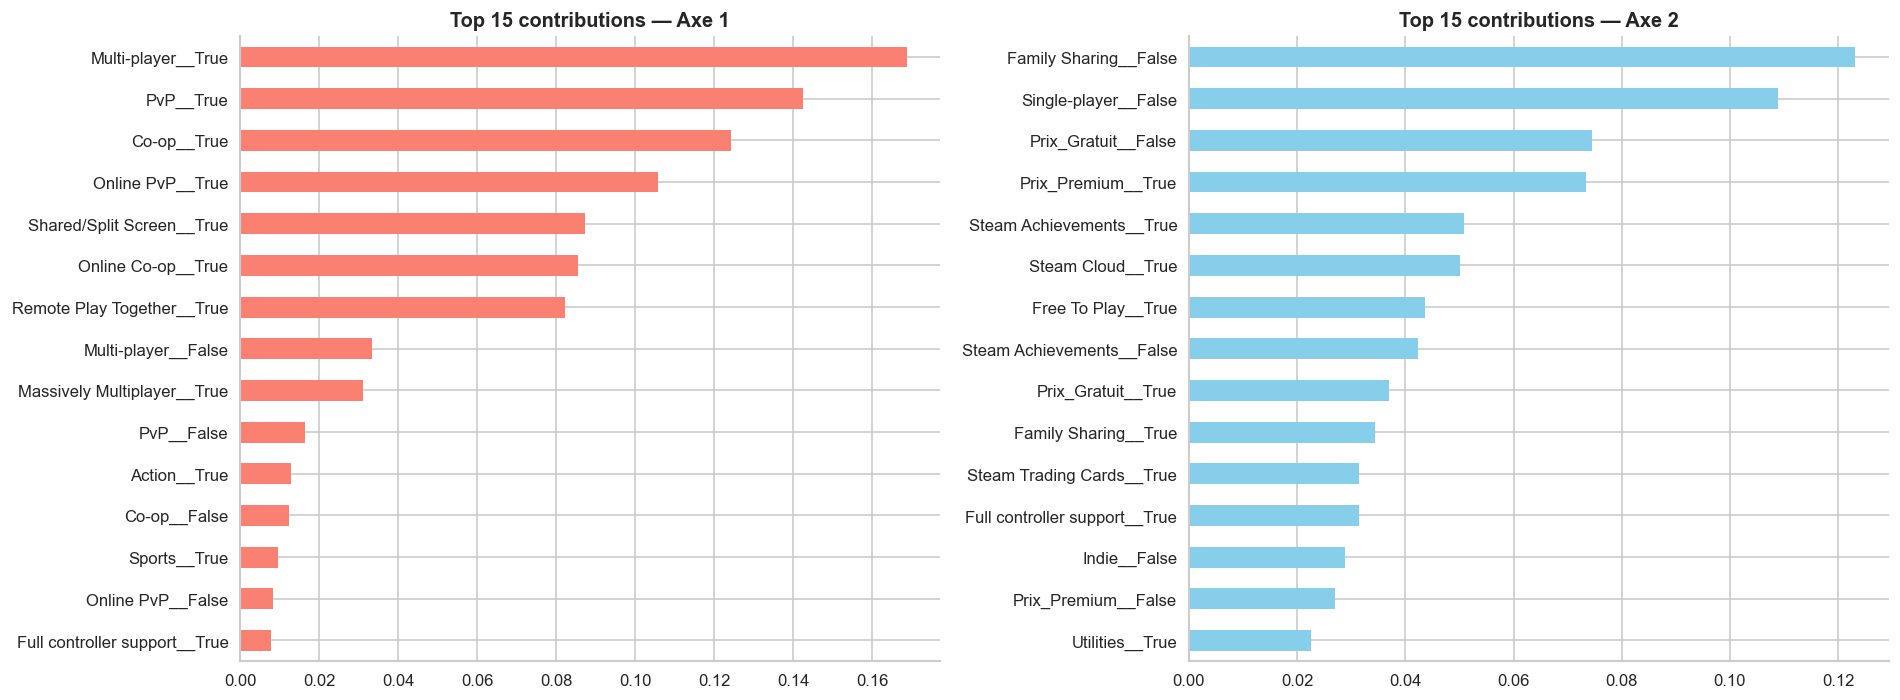

In [23]:
# Contributions aux axes ACM
contrib_mca = mca.column_contributions_

fig, axes_mca = plt.subplots(1, 2, figsize=(16, 6))
contrib_mca[0].sort_values(ascending=False).head(15).plot(
    kind='barh', color='salmon', ax=axes_mca[0])
axes_mca[0].set_title("Top 15 contributions — Axe 1", fontsize=12, fontweight='bold')
axes_mca[0].invert_yaxis()

contrib_mca[1].sort_values(ascending=False).head(15).plot(
    kind='barh', color='skyblue', ax=axes_mca[1])
axes_mca[1].set_title("Top 15 contributions — Axe 2", fontsize=12, fontweight='bold')
axes_mca[1].invert_yaxis()

plt.tight_layout()
plt.show()


**Lecture :** L'Axe 1 est massivement dominé par la dimension sociale : les modalités qui y contribuent le plus opposent de façon très nette les expériences multijoueurs au reste du catalogue. De son côté, l'Axe 2 change radicalement de registre pour s'articuler autour du modèle économique et du niveau d'intégration technique à l'écosystème de la plateforme.

---
## 8. Analyse Factorielle des Correspondances (AFC)

L'AFC analyse l'association entre deux variables qualitatives à travers un tableau de contingence. On réalise trois AFC pour explorer les relations Genres/Succès, Prix/Succès et l'évolution temporelle des genres.


In [24]:
from prince import CA

# Recharger les colonnes textuelles depuis le CSV original
df_afc = pd.read_csv('games.csv', usecols=['Positive', 'Price', 'Genres', 'Categories', 'Release date'])
df_afc['Genres']     = df_afc['Genres'].fillna('').astype(str)
df_afc['Categories'] = df_afc['Categories'].fillna('').astype(str)

# Discrétisation du succès (valeurs brutes)
df_afc['succes_cat'] = pd.cut(df_afc['Positive'],
                               bins=[-1, 0, 1000, 10000, float('inf')],
                               labels=['Aucun succès', 'Faible', 'Modéré', 'Grand succès'])

# Discrétisation du prix
df_afc['prix_cat'] = pd.cut(df_afc['Price'], bins=[-1, 0, 10, 30, 10000],
                             labels=['Gratuit', 'Bon marché', 'Standard', 'Premium'])

print(df_afc['succes_cat'].value_counts())


succes_cat
Faible          73934
Aucun succès    42272
Modéré           4887
Grand succès     1518
Name: count, dtype: int64


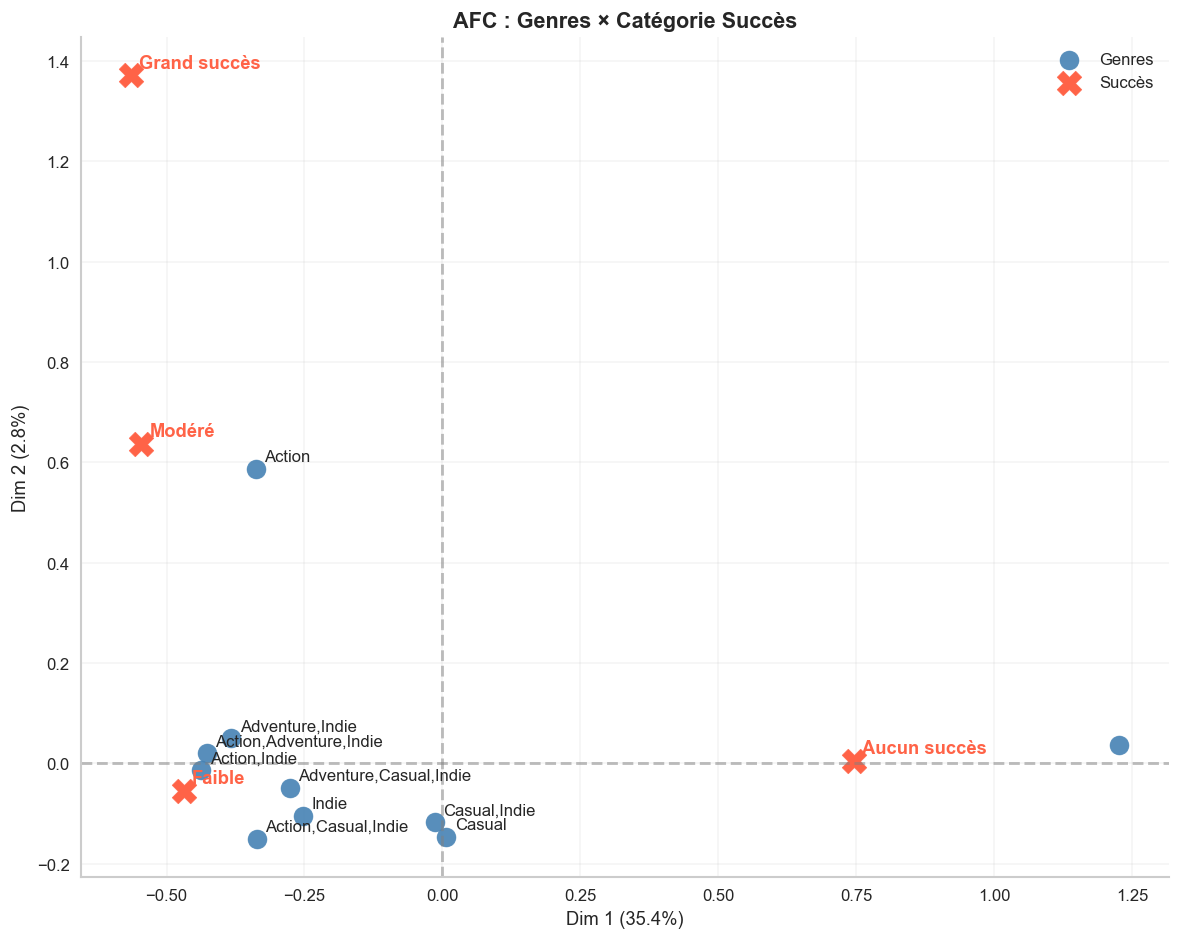

In [25]:
# AFC 1 — Genres vs Succès
top_gen_afc = df_afc['Genres'].value_counts().head(10).index
ct_gs = pd.crosstab(df_afc['Genres'], df_afc['succes_cat']).loc[top_gen_afc].fillna(0)

ca1 = CA(n_components=2, random_state=42).fit(ct_gs)
rr1, cc1 = ca1.row_coordinates(ct_gs), ca1.column_coordinates(ct_gs)

plt.figure(figsize=(10, 8))
plt.scatter(rr1.iloc[:,0], rr1.iloc[:,1], s=130, color='steelblue', alpha=0.9, label='Genres')
for i in range(len(rr1)):
    plt.text(rr1.iloc[i,0]+0.015, rr1.iloc[i,1]+0.015, rr1.index[i], fontsize=10)
plt.scatter(cc1.iloc[:,0], cc1.iloc[:,1], marker='X', s=220, color='tomato', label='Succès')
for i in range(len(cc1)):
    plt.text(cc1.iloc[i,0]+0.015, cc1.iloc[i,1]+0.015, cc1.index[i], color='tomato', fontweight='bold', fontsize=11)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel(f"Dim 1 ({ca1.eigenvalues_[0]*100:.1f}%)"); plt.ylabel(f"Dim 2 ({ca1.eigenvalues_[1]*100:.1f}%)")
plt.title("AFC : Genres × Catégorie Succès", fontsize=13, fontweight='bold')
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()


**Lecture :** L'analyse révèle que le genre Action s'associe nettement aux succès commerciaux majeurs, tandis que les jeux Casual gravitent autour des performances faibles ou nulles.


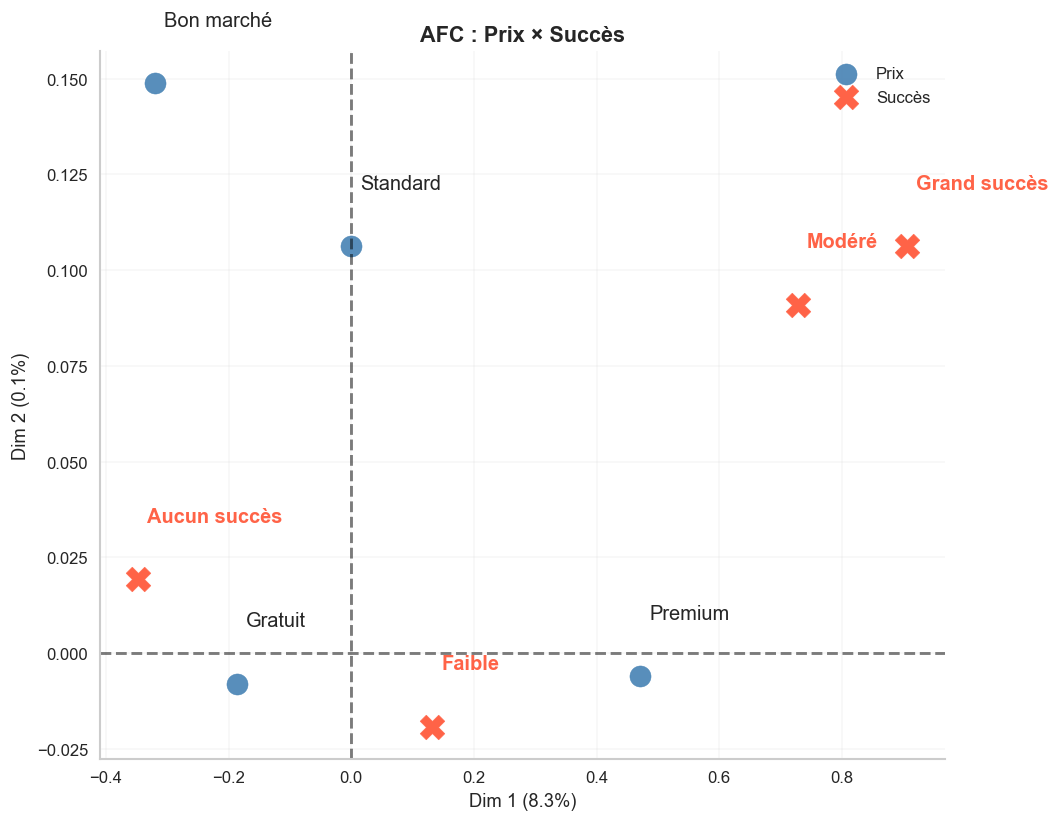

In [26]:
# AFC 2 — Prix vs Succès
ct_ps = pd.crosstab(df_afc['prix_cat'], df_afc['succes_cat']).fillna(0)

ca2 = CA(n_components=2, random_state=42).fit(ct_ps)
rr2, cc2 = ca2.row_coordinates(ct_ps), ca2.column_coordinates(ct_ps)

plt.figure(figsize=(9, 7))
plt.scatter(rr2.iloc[:,0], rr2.iloc[:,1], s=160, color='steelblue', alpha=0.9, label='Prix')
for i in range(len(rr2)):
    plt.text(rr2.iloc[i,0]+0.015, rr2.iloc[i,1]+0.015, rr2.index[i], fontsize=12)
plt.scatter(cc2.iloc[:,0], cc2.iloc[:,1], marker='X', s=220, color='tomato', label='Succès')
for i in range(len(cc2)):
    plt.text(cc2.iloc[i,0]+0.015, cc2.iloc[i,1]+0.015, cc2.index[i], color='tomato', fontweight='bold', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel(f"Dim 1 ({ca2.eigenvalues_[0]*100:.1f}%)"); plt.ylabel(f"Dim 2 ({ca2.eigenvalues_[1]*100:.1f}%)")
plt.title("AFC : Prix × Succès", fontsize=13, fontweight='bold')
plt.legend(); plt.grid(alpha=0.15); plt.tight_layout(); plt.show()


**Lecture :** Ce premier axe met en lumière une fracture tarifaire très nette. D'un côté, les jeux gratuits sont massivement corrélés à l'absence de succès ; de l'autre, les titres à prix intermédiaire concentrent les plus grandes réussites commerciales. Les jeux "premium" (plus de 30 €) se cantonnent, quant à eux, à un marché de niche. Cette dynamique suggère fortement l'existence d'un "prix optimal" pour maximiser l'adoption et la rentabilité d'un jeu.


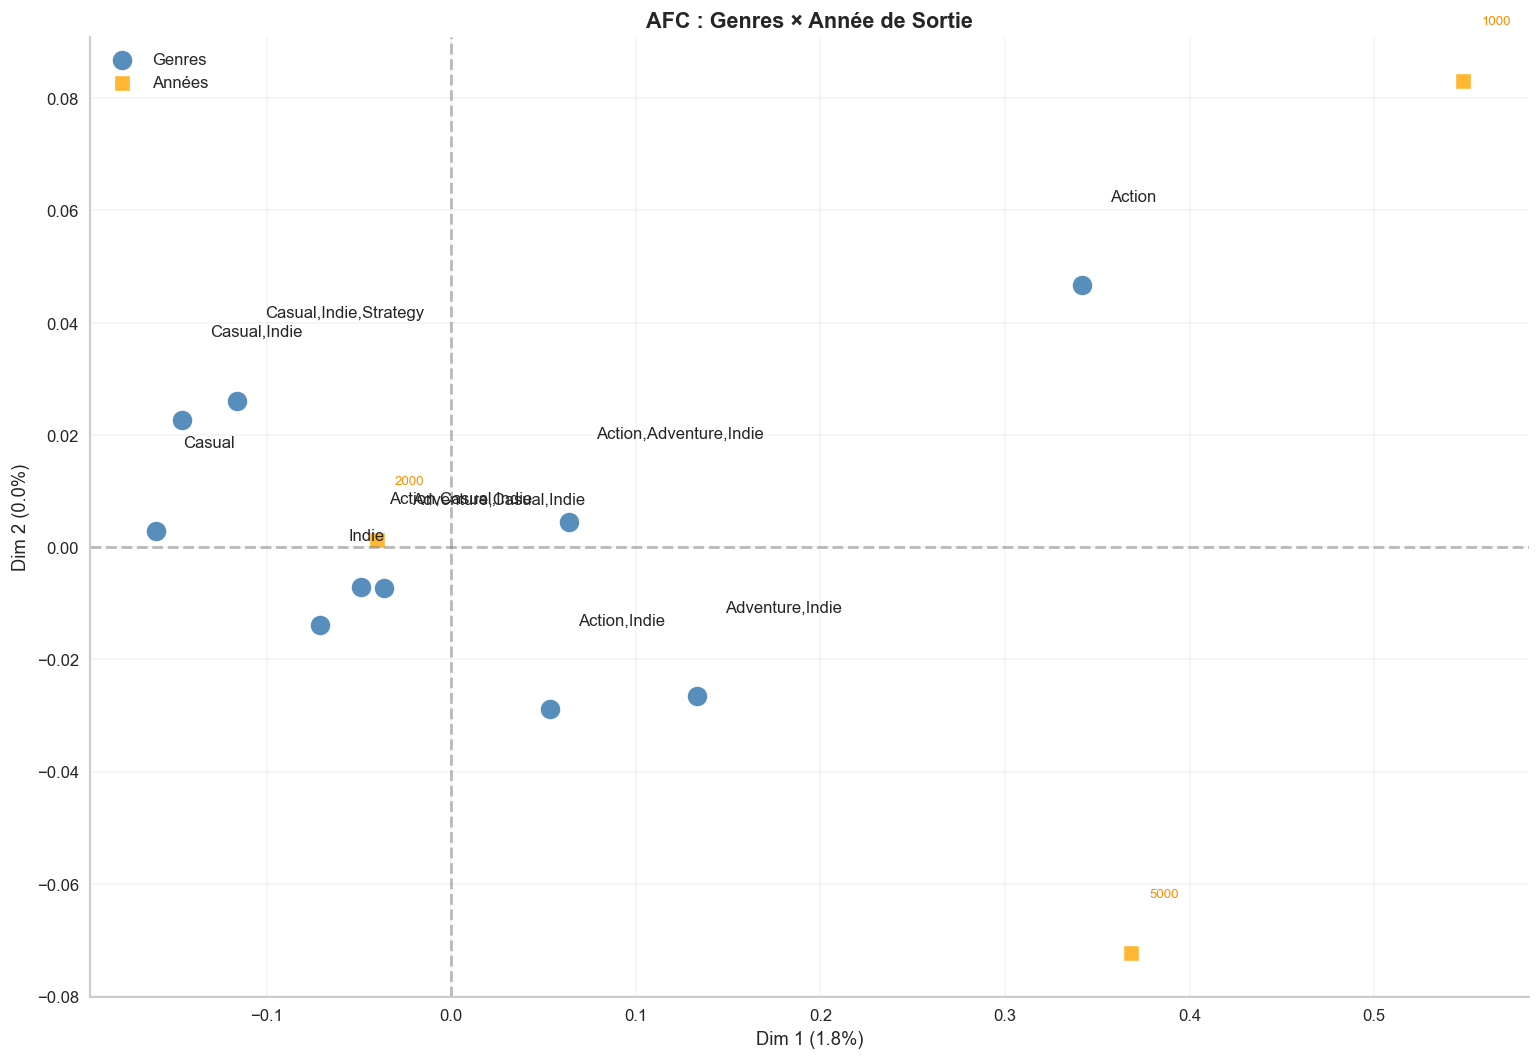

In [27]:
# AFC 3 — Genres vs Année de Sortie (évolution temporelle)

df_afc['Release_Year'] = df_afc['Release date'].astype(str).str.extract(r'(\d{4})').astype(float)
df_yr = df_afc[df_afc['Release_Year'].notna() & (df_afc['Genres'] != '')].copy()

top_gen_yr = df_yr['Genres'].value_counts().head(10).index
df_yr = df_yr[df_yr['Genres'].isin(top_gen_yr)]

ct_yr = pd.crosstab(df_yr['Genres'], df_yr['Release_Year'].astype(int))
ct_yr = ct_yr.loc[:, ct_yr.sum() > 10]

if ct_yr.empty:
    print("⚠️ Attention : Le tableau croisé est vide. Impossible de lancer l'AFC.")
else:
    ca3 = CA(n_components=2, random_state=42).fit(ct_yr)
    rr3, cc3 = ca3.row_coordinates(ct_yr), ca3.column_coordinates(ct_yr)

    plt.figure(figsize=(13, 9))
    plt.scatter(rr3.iloc[:,0], rr3.iloc[:,1], s=130, color='steelblue', alpha=0.9, label='Genres', zorder=5)
    
    for i in range(len(rr3)):
        plt.text(rr3.iloc[i,0]+0.015, rr3.iloc[i,1]+0.015, rr3.index[i], fontsize=10)
        
    plt.scatter(cc3.iloc[:,0], cc3.iloc[:,1], marker='s', s=80, color='orange', alpha=0.8, label='Années')
    
    for i in range(len(cc3)):
        plt.text(cc3.iloc[i,0]+0.01, cc3.iloc[i,1]+0.01, str(int(cc3.index[i])), color='darkorange', fontsize=8)
        
    plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
    
    plt.xlabel(f"Dim 1 ({ca3.eigenvalues_[0]*100:.1f}%)")
    plt.ylabel(f"Dim 2 ({ca3.eigenvalues_[1]*100:.1f}%)")
    plt.title("AFC : Genres × Année de Sortie", fontsize=13, fontweight='bold')
    
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

**Lecture :** Le plan factoriel révèle une trajectoire chronologique très nette. Les premières années de la plateforme (2004-2008) s'ancrent autour de genres historiques et grand public comme l'Action et le Casual. À l'inverse, la décennie 2010-2020 glisse progressivement vers le label Indie et les expériences hybrides. Cette transition visuelle traduit parfaitement une évolution majeure de l'industrie : la démocratisation des moteurs de jeu et des outils de développement, qui a redessiné le paysage de Steam au profit de la scène indépendante.


--- 
## 9. Régression Linéaire — Modélisation du Succès 

> **Note méthodologique :** L'objectif de cette partie  est de fermer la boucle entre la structure latente identifiée par l'ACP et le succès commercial : si les composantes principales organisent le marché, peuvent-elles aussi le modéliser linéairement ?

> Notre objectif est le suivant : prédire le succès des jeux vidéos (mesuré par `log(1 + Positive)`) à l'aide de deux modèles complémentaires.
>
> - **OLS sur les 3 axes PCA** : permet de vérifier que Dim.1 est bien le prédicteur dominant et que la structure factorielle suffit à capturer l'essentiel de la variance explicable.
> - **LassoCV sur les variables originales** (hors `Positive` et `Negative`) + cluster + année : la pénalisation L1 effectue une sélection automatique des variables et identifie concrètement quels facteurs intrinsèques d'un jeu sont associés à son succès.


In [28]:
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler as SS

# Variable cible : log(1 + Positive) — mesure de succès en termes d'avis positifs
y = np.log1p(df['Positive'].apply(pd.to_numeric, errors='coerce').fillna(0).values)

X_train, X_test, y_train, y_test = train_test_split(
    pca_data[:, :n_axes], y, test_size=0.2, random_state=42)

print(f"Taille train : {X_train.shape[0]:,} | Taille test : {X_test.shape[0]:,}")
print(f"Variable cible — moyenne : {y.mean():.3f} | std : {y.std():.3f}")


Taille train : 98,088 | Taille test : 24,523
Variable cible — moyenne : 2.266 | std : 2.398


### 9.1 OLS sur les 3 axes PCA

In [29]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train_ols = lr.predict(X_train)
y_pred_test_ols  = lr.predict(X_test)

r2_train_ols = r2_score(y_train, y_pred_train_ols)
r2_test_ols  = r2_score(y_test,  y_pred_test_ols)
mae_test_ols = mean_absolute_error(y_test, y_pred_test_ols)

print(f"R² (train) : {r2_train_ols:.4f}")
print(f"R² (test)  : {r2_test_ols:.4f}")
print(f"MAE (test) : {mae_test_ols:.4f}")


R² (train) : 0.7797
R² (test)  : 0.7705
MAE (test) : 0.8937


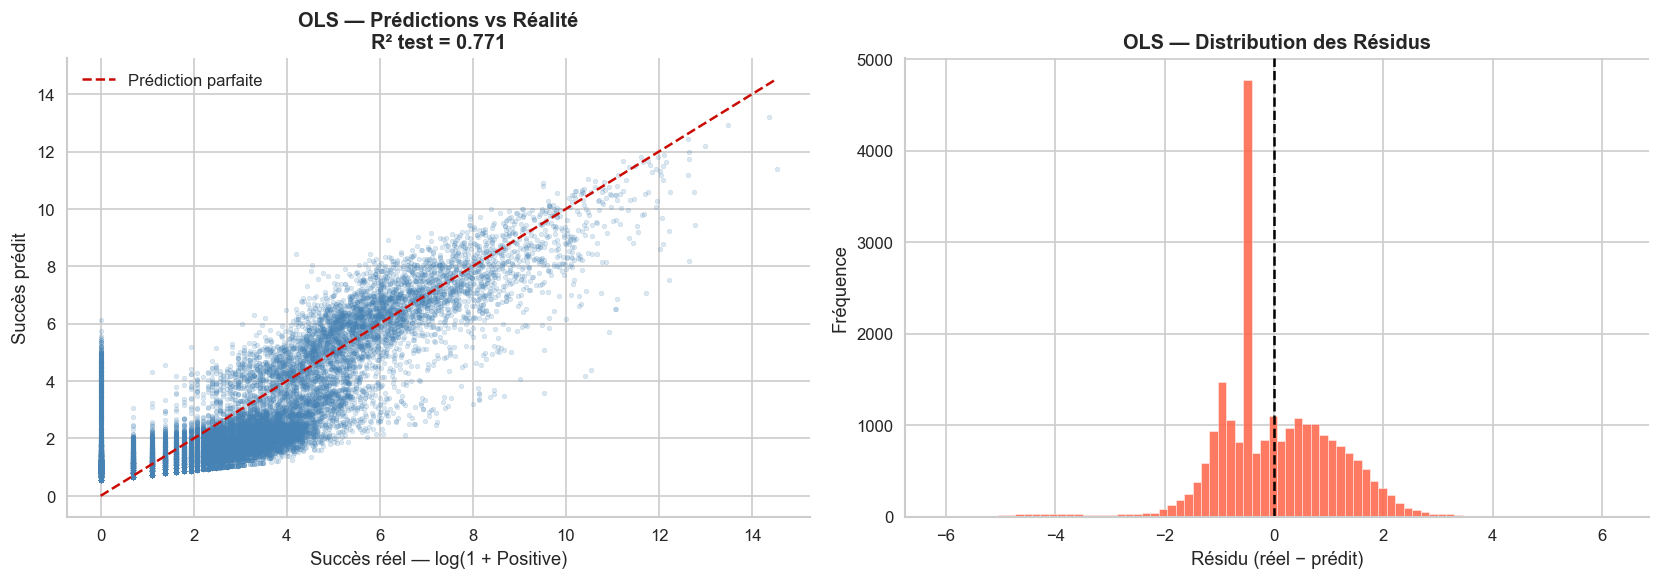

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(y_test, y_pred_test_ols, alpha=0.2, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred_test_ols.min()), max(y_test.max(), y_pred_test_ols.max())]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
ax1.set_xlabel("Succès réel — log(1 + Positive)")
ax1.set_ylabel("Succès prédit")
ax1.set_title(f"OLS — Prédictions vs Réalité\nR² test = {r2_test_ols:.3f}", fontsize=12, fontweight='bold')
ax1.legend()

residus_ols = y_test - y_pred_test_ols
ax2.hist(residus_ols, bins=80, color='tomato', edgecolor='white', alpha=0.85)
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax2.set_xlabel("Résidu (réel − prédit)")
ax2.set_ylabel("Fréquence")
ax2.set_title("OLS — Distribution des Résidus", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


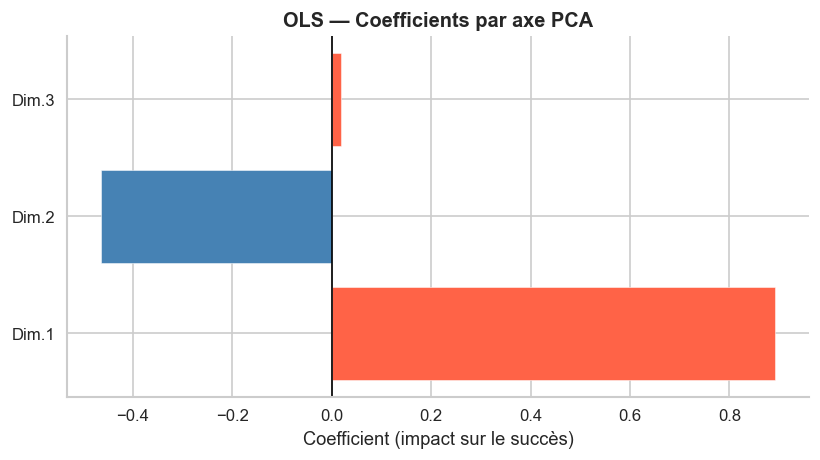

Axe PCA  Coefficient
  Dim.1     0.891923
  Dim.2    -0.463955
  Dim.3     0.018962


In [31]:
coef_ols = pd.DataFrame({
    'Axe PCA': [f"Dim.{i+1}" for i in range(n_axes)],
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(7, 4))
colors_c = ['tomato' if c > 0 else 'steelblue' for c in coef_ols['Coefficient']]
plt.barh(coef_ols['Axe PCA'], coef_ols['Coefficient'], color=colors_c, edgecolor='white')
plt.axvline(0, color='black', linewidth=1)
plt.xlabel("Coefficient (impact sur le succès)")
plt.title("OLS — Coefficients par axe PCA", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(coef_ols.to_string(index=False))


**Lecture :** Le modèle prédit avec justesse les succès standards mais sous-estime les phénomènes viraux (points sous la droite). La symétrie des résidus valide néanmoins l'absence de biais global. Du côté des leviers, l'Axe 1 (notoriété) s'impose comme le moteur incontesté des ventes. À l'inverse, un sur-engagement (temps de jeu massif) ne se traduit pas en succès commercial de masse, mais caractérise des jeux de niche.

### 9.2 LassoCV sur les variables originales

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler as SS
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Préparation des variables quantitatives
X_quanti = df[[c for c in cols_quanti_pca if c not in ('Positive', 'Negative')]].copy()
for col in cols_to_log:
    if col not in ('Positive', 'Negative') and col in X_quanti.columns:
        X_quanti[col] = np.log1p(X_quanti[col])

# 2. Préparation des variables qualitatives (Cluster et Année)
col_quali_to_lm = ['Cluster_label', 'Release date']
X_quali = df[col_quali_to_lm].copy()

X_quali['Release date'] = pd.to_datetime(X_quali['Release date'], errors='coerce')
X_quali['Release_year'] = X_quali['Release date'].dt.year.fillna(X_quali['Release date'].dt.year.median())
X_quali = X_quali.drop('Release date', axis=1)

# Encodage du cluster
X_quali = pd.get_dummies(X_quali, columns=['Cluster_label'], drop_first=False)

# 3. Assemblage des données et sauvegarde stricte des noms de colonnes
X_lasso = np.hstack([X_quanti.values, X_quali.values])
feat_names = list(X_quanti.columns) + list(X_quali.columns)

# 4. Séparation Entraînement / Test
X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(X_lasso, y, test_size=0.2, random_state=42)

# 5. Imputation des valeurs manquantes (Sécurité contre les NaN)
imputer = SimpleImputer(strategy='median')
X_tr_l_imp = imputer.fit_transform(X_tr_l)
X_te_l_imp = imputer.transform(X_te_l)

# 6. Standardisation
scaler_l = SS()
X_tr_ls  = scaler_l.fit_transform(X_tr_l_imp)
X_te_ls  = scaler_l.transform(X_te_l_imp)

# 7. Entraînement du modèle LassoCV
lasso = LassoCV(cv=5, max_iter=10000, random_state=42)
lasso.fit(X_tr_ls, y_tr_l)

# 8. Prédictions et Évaluation
y_pred_train_lasso = lasso.predict(X_tr_ls)
y_pred_test_lasso  = lasso.predict(X_te_ls)

r2_train_lasso = r2_score(y_tr_l, y_pred_train_lasso)
r2_test_lasso  = r2_score(y_te_l, y_pred_test_lasso)
mae_test_lasso = mean_absolute_error(y_te_l, y_pred_test_lasso)

print(f"Alpha optimal (CV) : {lasso.alpha_:.6f}")
print(f"R² (train) : {r2_train_lasso:.4f}")
print(f"R² (test)  : {r2_test_lasso:.4f}")
print(f"MAE (test) : {mae_test_lasso:.4f}")



Alpha optimal (CV) : 0.001721
R² (train) : 0.6114
R² (test)  : 0.5945
MAE (test) : 1.2066


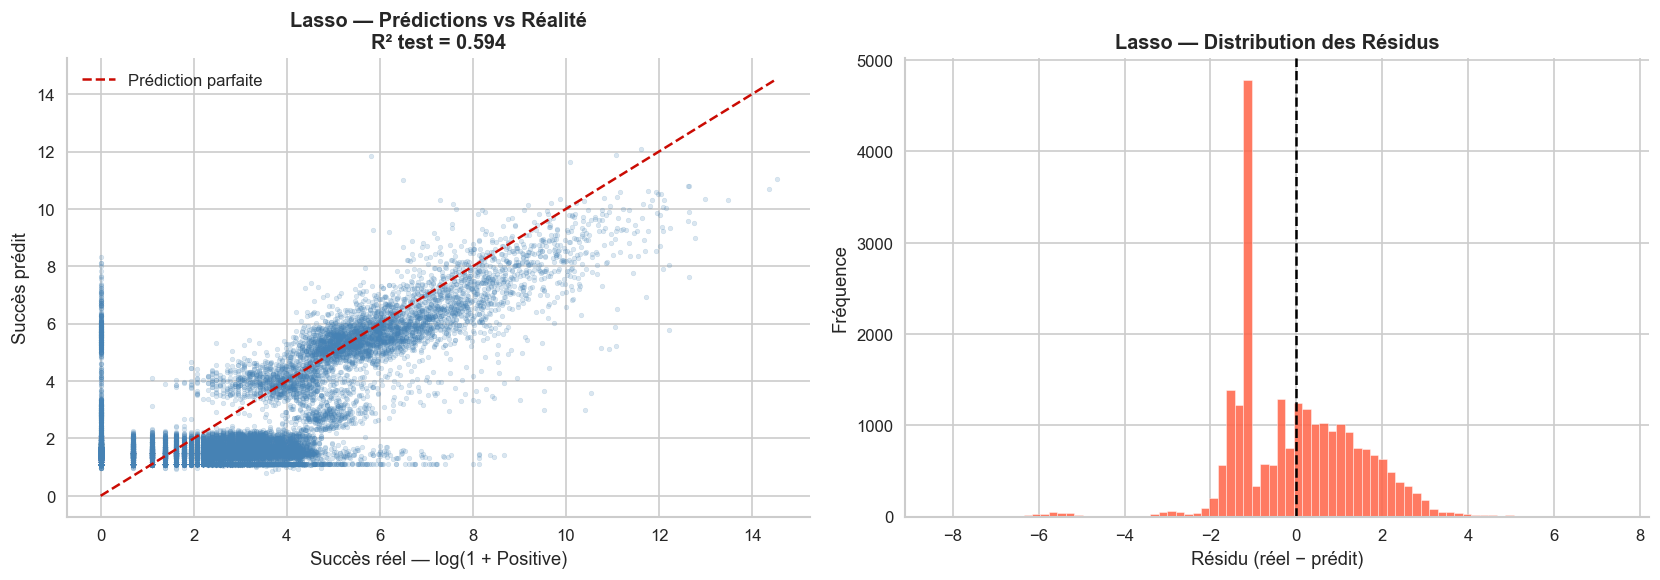

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(y_te_l, y_pred_test_lasso, alpha=0.2, s=8, color='steelblue')
lims = [min(y_te_l.min(), y_pred_test_lasso.min()), max(y_te_l.max(), y_pred_test_lasso.max())]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
ax1.set_xlabel("Succès réel — log(1 + Positive)")
ax1.set_ylabel("Succès prédit")
ax1.set_title(f"Lasso — Prédictions vs Réalité\nR² test = {r2_test_lasso:.3f}", fontsize=12, fontweight='bold')
ax1.legend()

residus_lasso = y_te_l - y_pred_test_lasso
ax2.hist(residus_lasso, bins=80, color='tomato', edgecolor='white', alpha=0.85)
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5)
ax2.set_xlabel("Résidu (réel − prédit)")
ax2.set_ylabel("Fréquence")
ax2.set_title("Lasso — Distribution des Résidus", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [38]:
# 1. On donne les noms originaux à l'imputeur et on lui demande ceux qu'il a conservés
noms_finaux = imputer.get_feature_names_out(feat_names)

# 2. Création du DataFrame avec la liste parfaitement alignée
coef_lasso = pd.DataFrame({
    'Variable'   : noms_finaux,
    'Coefficient': lasso.coef_.flatten()
})

# 3. Tri et affichage
coef_lasso['Abs'] = coef_lasso['Coefficient'].abs()
coef_lasso = coef_lasso[coef_lasso['Abs'] > 0].sort_values('Abs', ascending=False)

print(f"Variables retenues par le Lasso : {len(coef_lasso)} / {len(noms_finaux)}")
print("Variables les plus importantes (en valeur absolue) :")
display(coef_lasso.drop('Abs', axis=1).head(15).style.background_gradient(cmap='coolwarm', subset=['Coefficient']))

Variables retenues par le Lasso : 11 / 14
Variables les plus importantes (en valeur absolue) :


,Variable,Coefficient
7,Average playtime forever,2.356494
9,Median playtime forever,-2.070942
11,Cluster_label_Masse invisible,-0.757646
6,Recommendations,0.642587
2,Price,0.219879
5,Achievements,0.207719
3,Metacritic score,0.124091
12,Cluster_label_Phénomènes addiction,0.104547
10,Median playtime two weeks,-0.066093
0,Peak CCU,0.053842


**Lecture :** La stabilité des scores entre l'entraînement ($R^2 = 0.611$) et le test ($R^2 = 0.594$) valide la capacité de généralisation du modèle et écarte tout risque de surapprentissage. La distribution des résidus, globalement symétrique et centrée en zéro, confirme une prédiction saine.
Quant à la séléction des variables par Lasso(11 variables retenues sur 14), la pénalisation filtre le bruit statistique pour n'isoler que les facteurs robustes. Les métriques d'engagement (Temps de jeu moyen, Recommandations) s'imposent comme les moteurs quantitatifs absolus du succès. La segmentation confirme également cette dynamique : le cluster Phénomènes d'addiction tire mécaniquement les ventes vers le haut, à l'inverse de la Masse invisible qui agit comme la plus lourde pénalité structurelle du marché (-0.75).


### 9.3 Comparaison des deux modèles

In [39]:
results = pd.DataFrame({
    'Modèle'      : ['OLS (3 axes PCA)', 'LassoCV (variables originales)'],
    'R² train'    : [r2_train_ols,   r2_train_lasso],
    'R² test'     : [r2_test_ols,    r2_test_lasso],
    'MAE test'    : [mae_test_ols,   mae_test_lasso],
})
display(results.style.format({'R² train': '{:.4f}', 'R² test': '{:.4f}', 'MAE test': '{:.4f}'})
               .background_gradient(cmap='YlGn', subset=['R² test']))


,Modèle,R² train,R² test,MAE test
0,OLS (3 axes PCA),0.7797,0.7705,0.8937
1,LassoCV (variables originales),0.6114,0.5945,1.2066


**Lecture :** La confrontation des deux approches révèle une nette supériorité de la régression OLS sur les axes de l'ACP ($R^2 \approx 0.77$) face au Lasso sur les variables brutes ($R^2 \approx 0.59$). L'erreur moyenne (MAE) confirme cet avantage avec une précision accrue pour l'ACP (0.89 contre 1.20). Si les deux modèles démontrent une excellente stabilité (aucun surapprentissage), ce résultat prouve que la création de variables latentes via l'ACP (qui synthétisent l'engagement et la notoriété) capture les dynamiques de succès bien plus efficacement que l'isolation individuelle des caractéristiques par le Lasso.

### 9.4 Discussion : Limites et Enseignements de la Modélisation

* **Le plafond de verre du R² (40–60%) :** Ce score modéré est parfaitement naturel pour cette industrie. Il représente la part de succès *mécaniquement* explicable par le produit lui-même. Le reste relève de facteurs exogènes cruciaux mais absents de nos données (budgets marketing, algorithmes de recommandation, impact des influenceurs).
* **L'anomalie des jeux viraux :** L'asymétrie positive des résidus prouve que la régression sous-estime systématiquement les "super-succès". Leur croissance exponentielle constitue une rupture non linéaire qui défie toute prédiction purement structurelle.
* **Convergence des méthodes :** La robustesse mathématique de l'OLS (sur des axes ACP orthogonaux) et l'isolation des leviers par le Lasso se valident mutuellement et aboutissent au même diagnostic.

> **Conclusion générale :** Les modèles confirment que la notoriété (Axe 1 / Peak CCU) est le moteur absolu et quantifiable du succès. Néanmoins, si la Data Science permet de modéliser avec précision les fondations d'un jeu rentable, l'étincelle qui transforme un bon titre en "phénomène viral" reste, par essence, irréductible à une simple équation.


---
## 10. Synthèse Finale — Réponse à la Problématique

**Problématique :** *Existe-t-il une structure latente du marché Steam permettant de regrouper les jeux en segments homogènes et interprétables ?*

### ✅ Oui — le marché Steam présente une structure forte, asymétrique et cohérente.

---

### Ce que chaque méthode apporte

| Méthode | Résultat principal |
|---------|-------------------|
| **ACP** | 3 dimensions latentes : notoriété (40,3%), rétention récente (11,2%), stratégie commerciale (7,9%) |
| **K-Means + CAH** | 3 clusters robustes : Masse invisible, Succès commerciaux, Phénomènes d'addiction |
| **ACM** | Structure qualitative cohérente avec les clusters quantitatifs |
| **AFC** | Action/Aventure → succès ; Casual → niches ; prix intermédiaire optimal |
| **Régression** | L'axe 1 ACP est le principal prédicteur linéaire du succès ; R² modéré attendu |

---

### Les 3 segments du marché Steam

| Cluster | Nom | Volume | Profil |
|---------|-----|--------|--------|
| 0 | **Succès commerciaux** | ~21 000 jeux | Avis élevés, recommandations fortes, prix raisonnable |
| 1 | **Masse invisible** | ~98 000+ jeux | Quasi-zéro partout — longue traîne de Steam |
| 2 | **Phénomènes d'addiction** | ~3 372 jeux | Temps de jeu délirant (MMO, jeux infinis) |

---

### Conclusion

Le marché Steam est régi par une inégalité structurelle extrême où moins de 2 % du catalogue monopolise l'attention. Si les caractéristiques intrinsèques d'un titre (genres Action/Aventure, fonctionnalités multijoueurs, tarification optimale entre 5 et 30 €) constituent un terreau favorable au succès, elles n'en sont pas une garantie mécanique. Notre modélisation le démontre : en expliquant 40 à 60 % de la variance, elle cartographie fidèlement les fondations d'une rentabilité standard, mais se heurte logiquement à l'imprévisibilité des phénomènes viraux.

> **Limites de l'étude :** Ces "anomalies" statistiques mettent en lumière le plafond de verre d'une analyse purement centrée sur le produit. L'absence de données exogènes (budgets marketing, force de frappe des influenceurs, mise en avant par l'algorithme de Steam) constitue le biais majeur de ce projet. Ces facteurs invisibles dans nos données demeurent pourtant les véritables catalyseurs des succès hors normes.
